In [1]:
import mace
import torch
import numpy as np
from pathlib import Path
from ase import Atoms
from mace.calculators import MACECalculator

import matplotlib.pyplot as plt

/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def compute_model_svd(model):
    """
    Iterates through all parameters of a MACE model and computes their SVD.
    Returns a dictionary mapping parameter names to their singular values.
    """
    svd_results = {}
    
    # .named_parameters() gives you the name and the actual tensor
    for name, param in model.named_parameters():
        # SVD only makes sense for floating point weights that require/store gradients
        if param.dtype not in [torch.float32, torch.float64]:
            continue
            
        # Clone and detach so we don't accidentally mess with the model's computation graph
        tensor = param.detach().cpu()
        
        # SVD requires at least a 2D matrix
        if tensor.dim() < 2:
            print(f"Skipping {name}: 1D weight vectors (like biases) cannot undergo SVD.")
            continue
            
        # If the tensor is 3D or higher, flatten it to a 2D matrix 
        # (combining all batch/feature dimensions except the last one)
        if tensor.dim() > 2:
            original_shape = list(tensor.shape)
            # Reshape to (Product of all dimensions except last, Last dimension)
            tensor = tensor.view(-1, original_shape[-1])
            print(f"Reshaped {name} from {original_shape} to {list(tensor.shape)} for SVD.")
        
        try:
            # Note: torch.linalg.svd is the preferred, modern version of torch.svd
            # We set compute_uv=False if you only care about the singular values (saves a lot of memory)
            S = torch.linalg.svdvals(tensor)
            svd_results[name] = S
        except RuntimeWarning as e:
            print(f"Could not compute SVD for {name}: {e}")
            
    return svd_results

# Example usage:
# svd_dict = compute_model_svd(mace_model)

In [6]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

model_path = f"{ROOT}/KAGGLE_DOWNLOAD/from_C2_v1/MACE.model"
model = torch.load(model_path, map_location="cpu")

/tmp/ipykernel_2203046/2079303584.py:2: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model = torch.load(model_path, map_location="cpu")
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [7]:
svd = compute_model_svd(model)

Skipping node_embedding.linear.weight: 1D weight vectors (like biases) cannot undergo SVD.
Skipping interactions.0.linear_up.weight: 1D weight vectors (like biases) cannot undergo SVD.
Skipping interactions.0.linear.weight: 1D weight vectors (like biases) cannot undergo SVD.
Skipping interactions.0.skip_tp.weight: 1D weight vectors (like biases) cannot undergo SVD.
Skipping interactions.1.linear_up.weight: 1D weight vectors (like biases) cannot undergo SVD.
Skipping interactions.1.linear.weight: 1D weight vectors (like biases) cannot undergo SVD.
Skipping interactions.1.skip_tp.weight: 1D weight vectors (like biases) cannot undergo SVD.
Reshaped products.0.symmetric_contractions.contractions.0.weights_max from [1, 23, 128] to [23, 128] for SVD.
Reshaped products.0.symmetric_contractions.contractions.0.weights.0 from [1, 4, 128] to [4, 128] for SVD.
Reshaped products.0.symmetric_contractions.contractions.0.weights.1 from [1, 1, 128] to [1, 128] for SVD.
Reshaped products.0.symmetric_con

In [8]:
svd

{'interactions.0.conv_tp_weights.layer0.weight': tensor([11.3039, 11.0258, 10.0008,  8.8526,  8.5580,  7.8340,  6.9397,  6.3415,
          6.2446,  5.3403]),
 'interactions.0.conv_tp_weights.layer1.weight': tensor([15.4301, 15.1053, 14.3313, 13.9033, 13.4884, 13.3119, 12.8200, 12.6524,
         12.2685, 11.9132, 11.5474, 11.2210, 11.1346, 10.8002, 10.4845, 10.2174,
          9.9832,  9.5132,  9.2925,  9.1371,  8.9218,  8.6466,  8.4855,  8.1899,
          7.9720,  7.7772,  7.7382,  7.6093,  7.2808,  7.1481,  6.8269,  6.7354,
          6.5195,  6.3214,  6.0256,  5.8571,  5.6804,  5.4430,  5.0968,  4.9849,
          4.6602,  4.4367,  4.2381,  3.9469,  3.8231,  3.6249,  3.4441,  3.3208,
          3.0149,  2.8073,  2.6473,  2.2053,  2.1791,  2.0366,  1.9191,  1.5412,
          1.3898,  1.3745,  1.3223,  1.0464,  0.7795,  0.6444,  0.4725,  0.2492]),
 'interactions.0.conv_tp_weights.layer2.weight': tensor([15.1218, 14.5953, 13.8745, 13.6219, 13.1815, 12.8868, 12.3348, 11.9375,
         11.806

In [25]:
def fitting(x, A, delta, alpha):
    return A/(x + delta)**alpha

In [26]:
from scipy.optimize import curve_fit

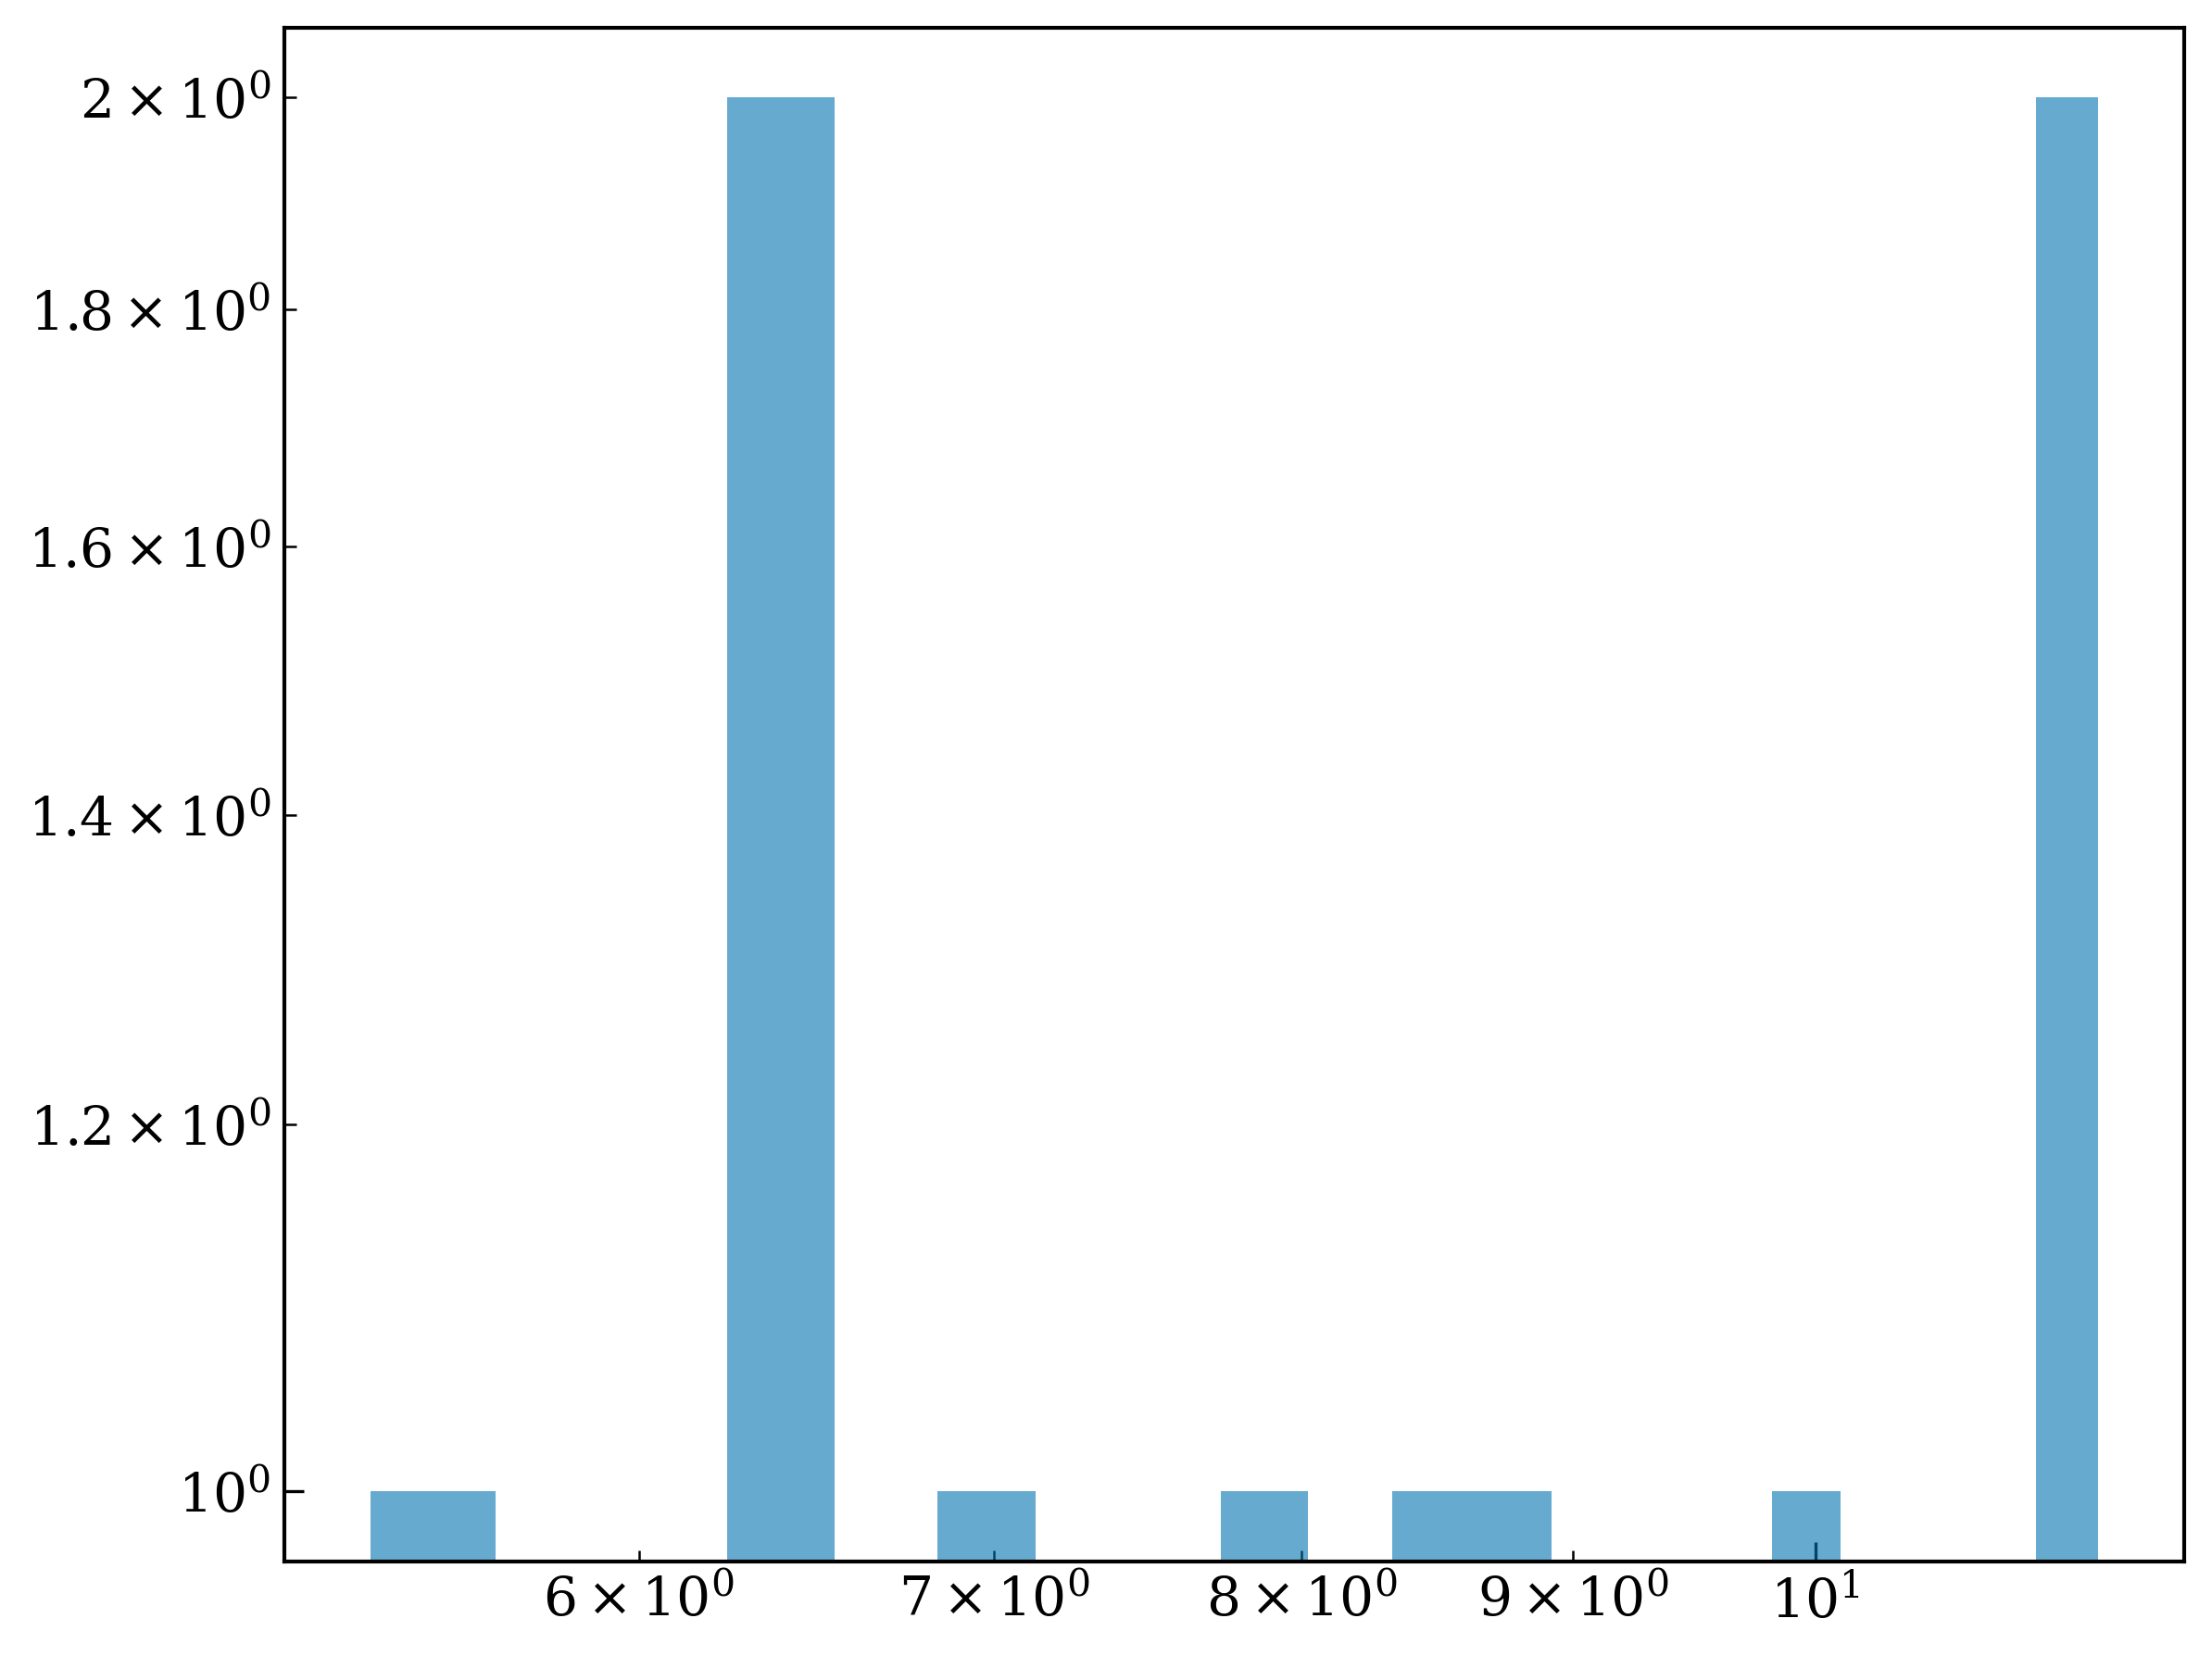

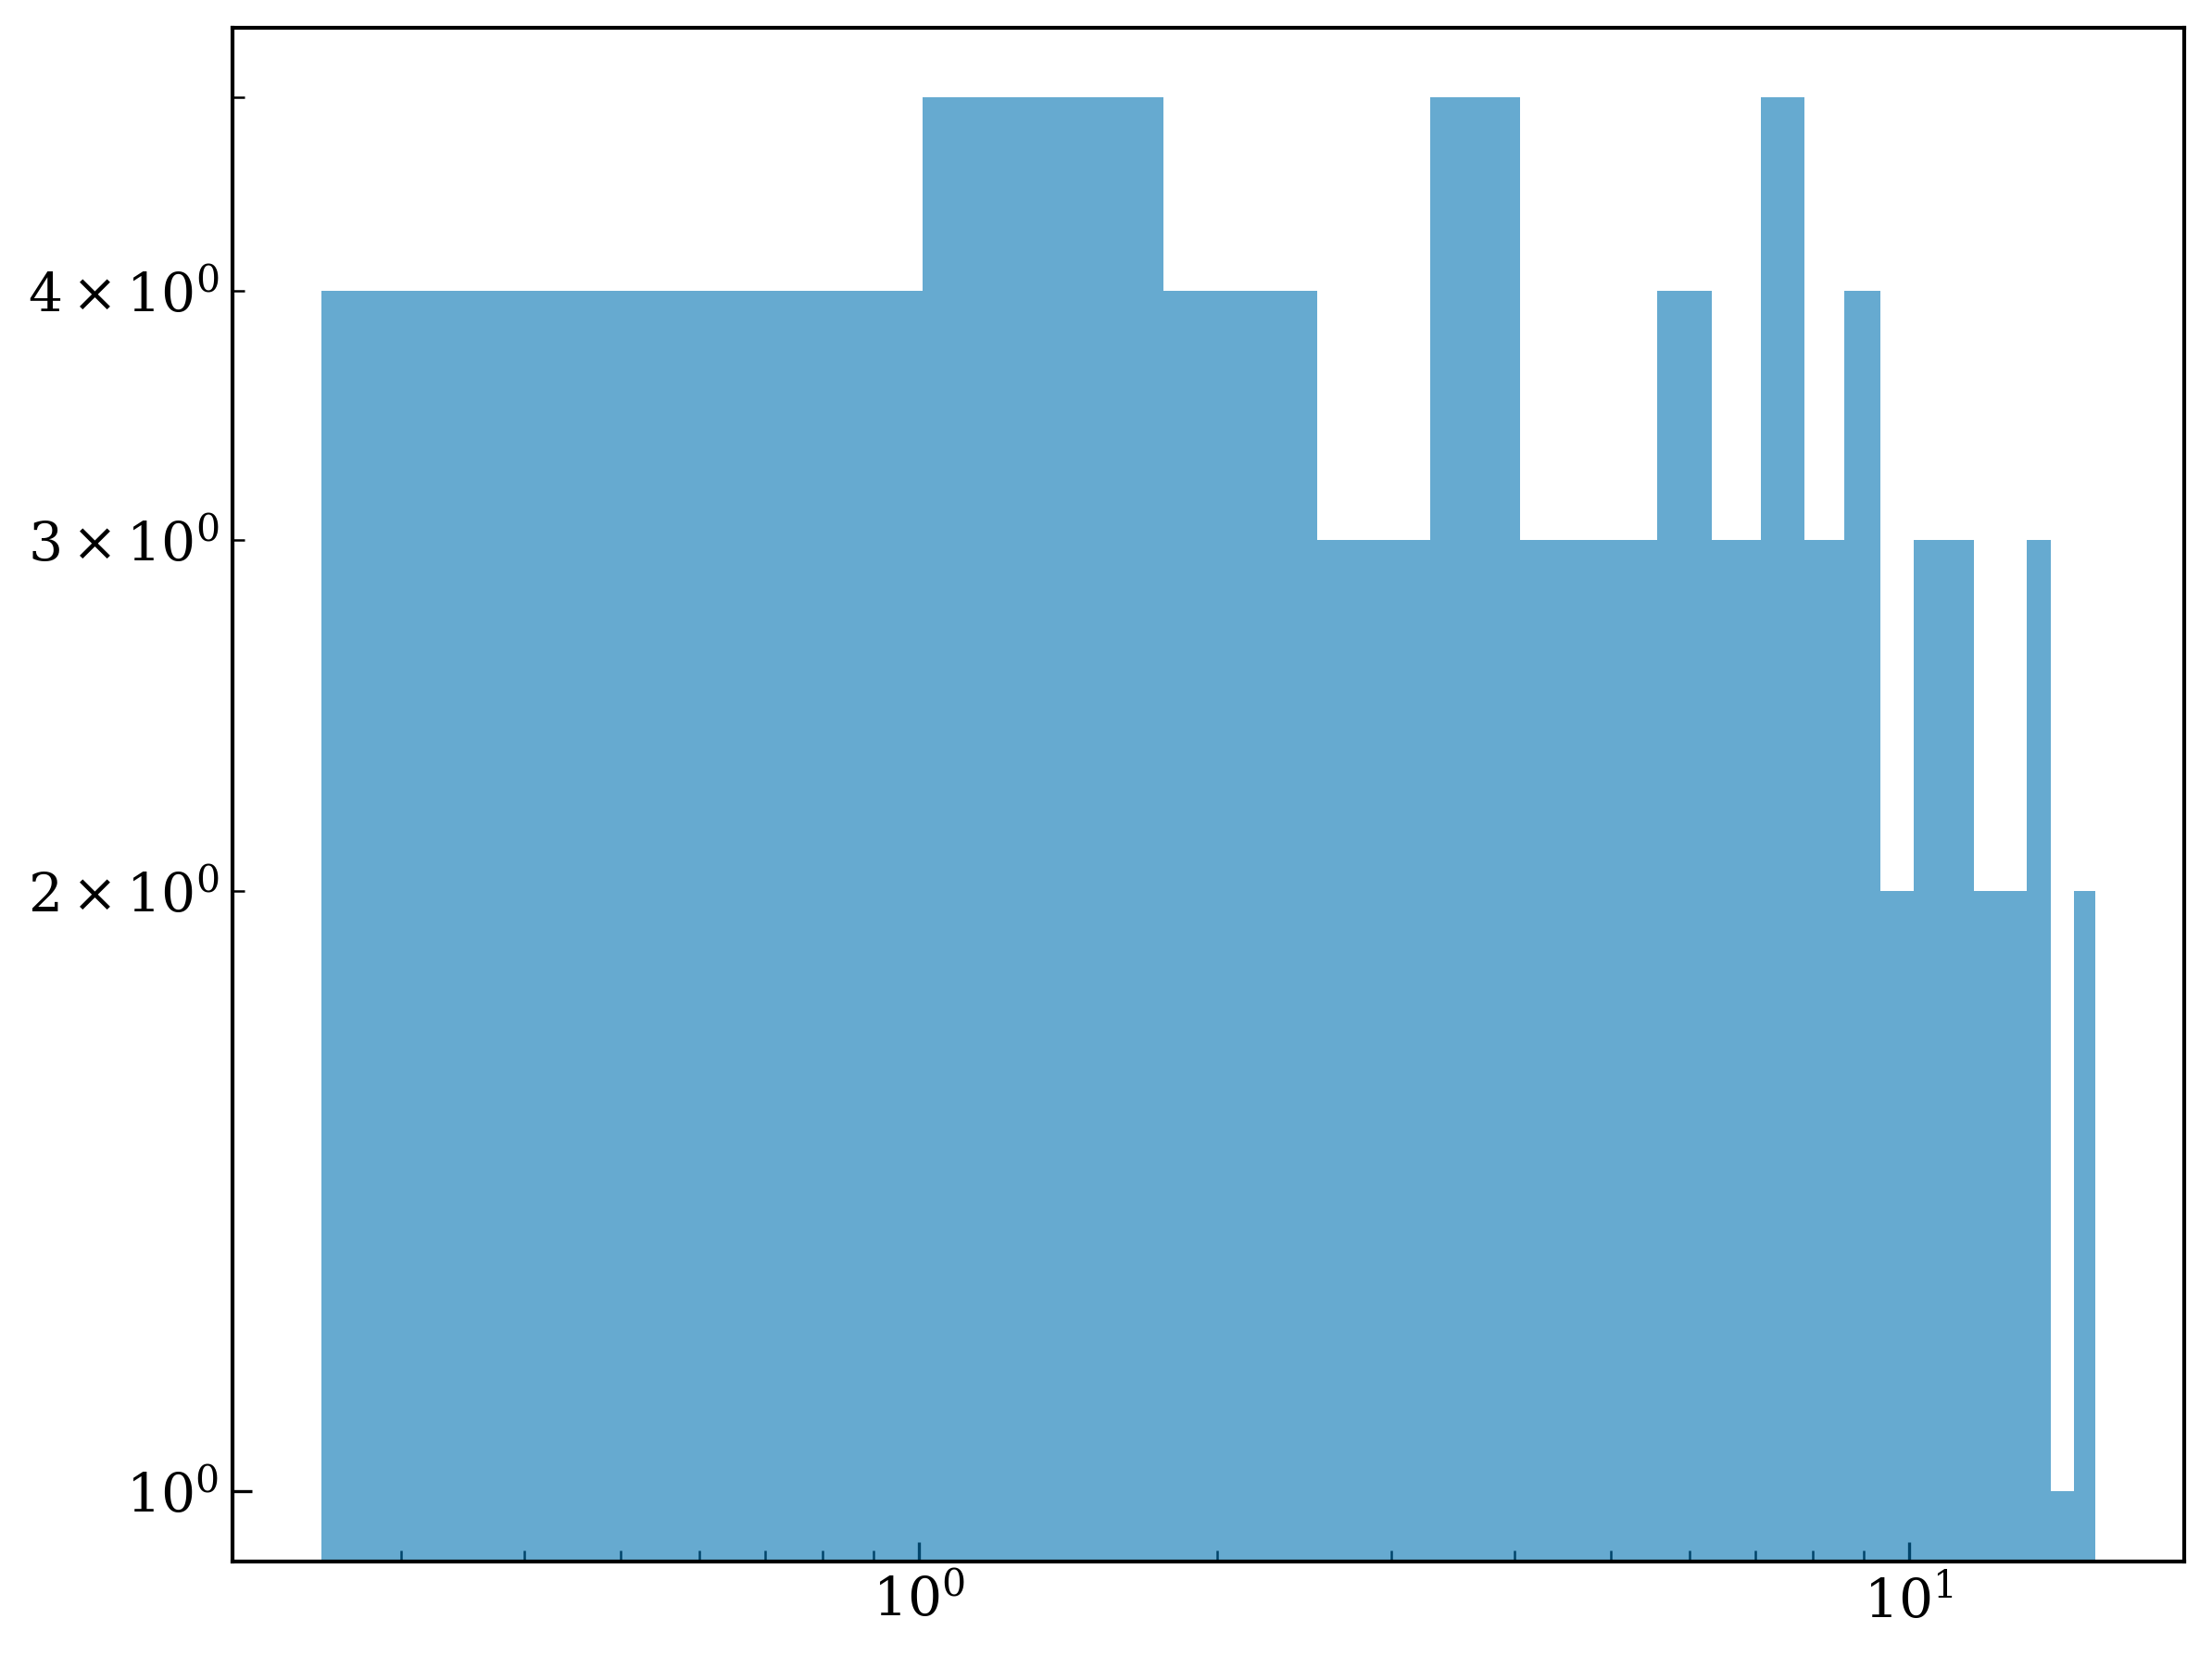

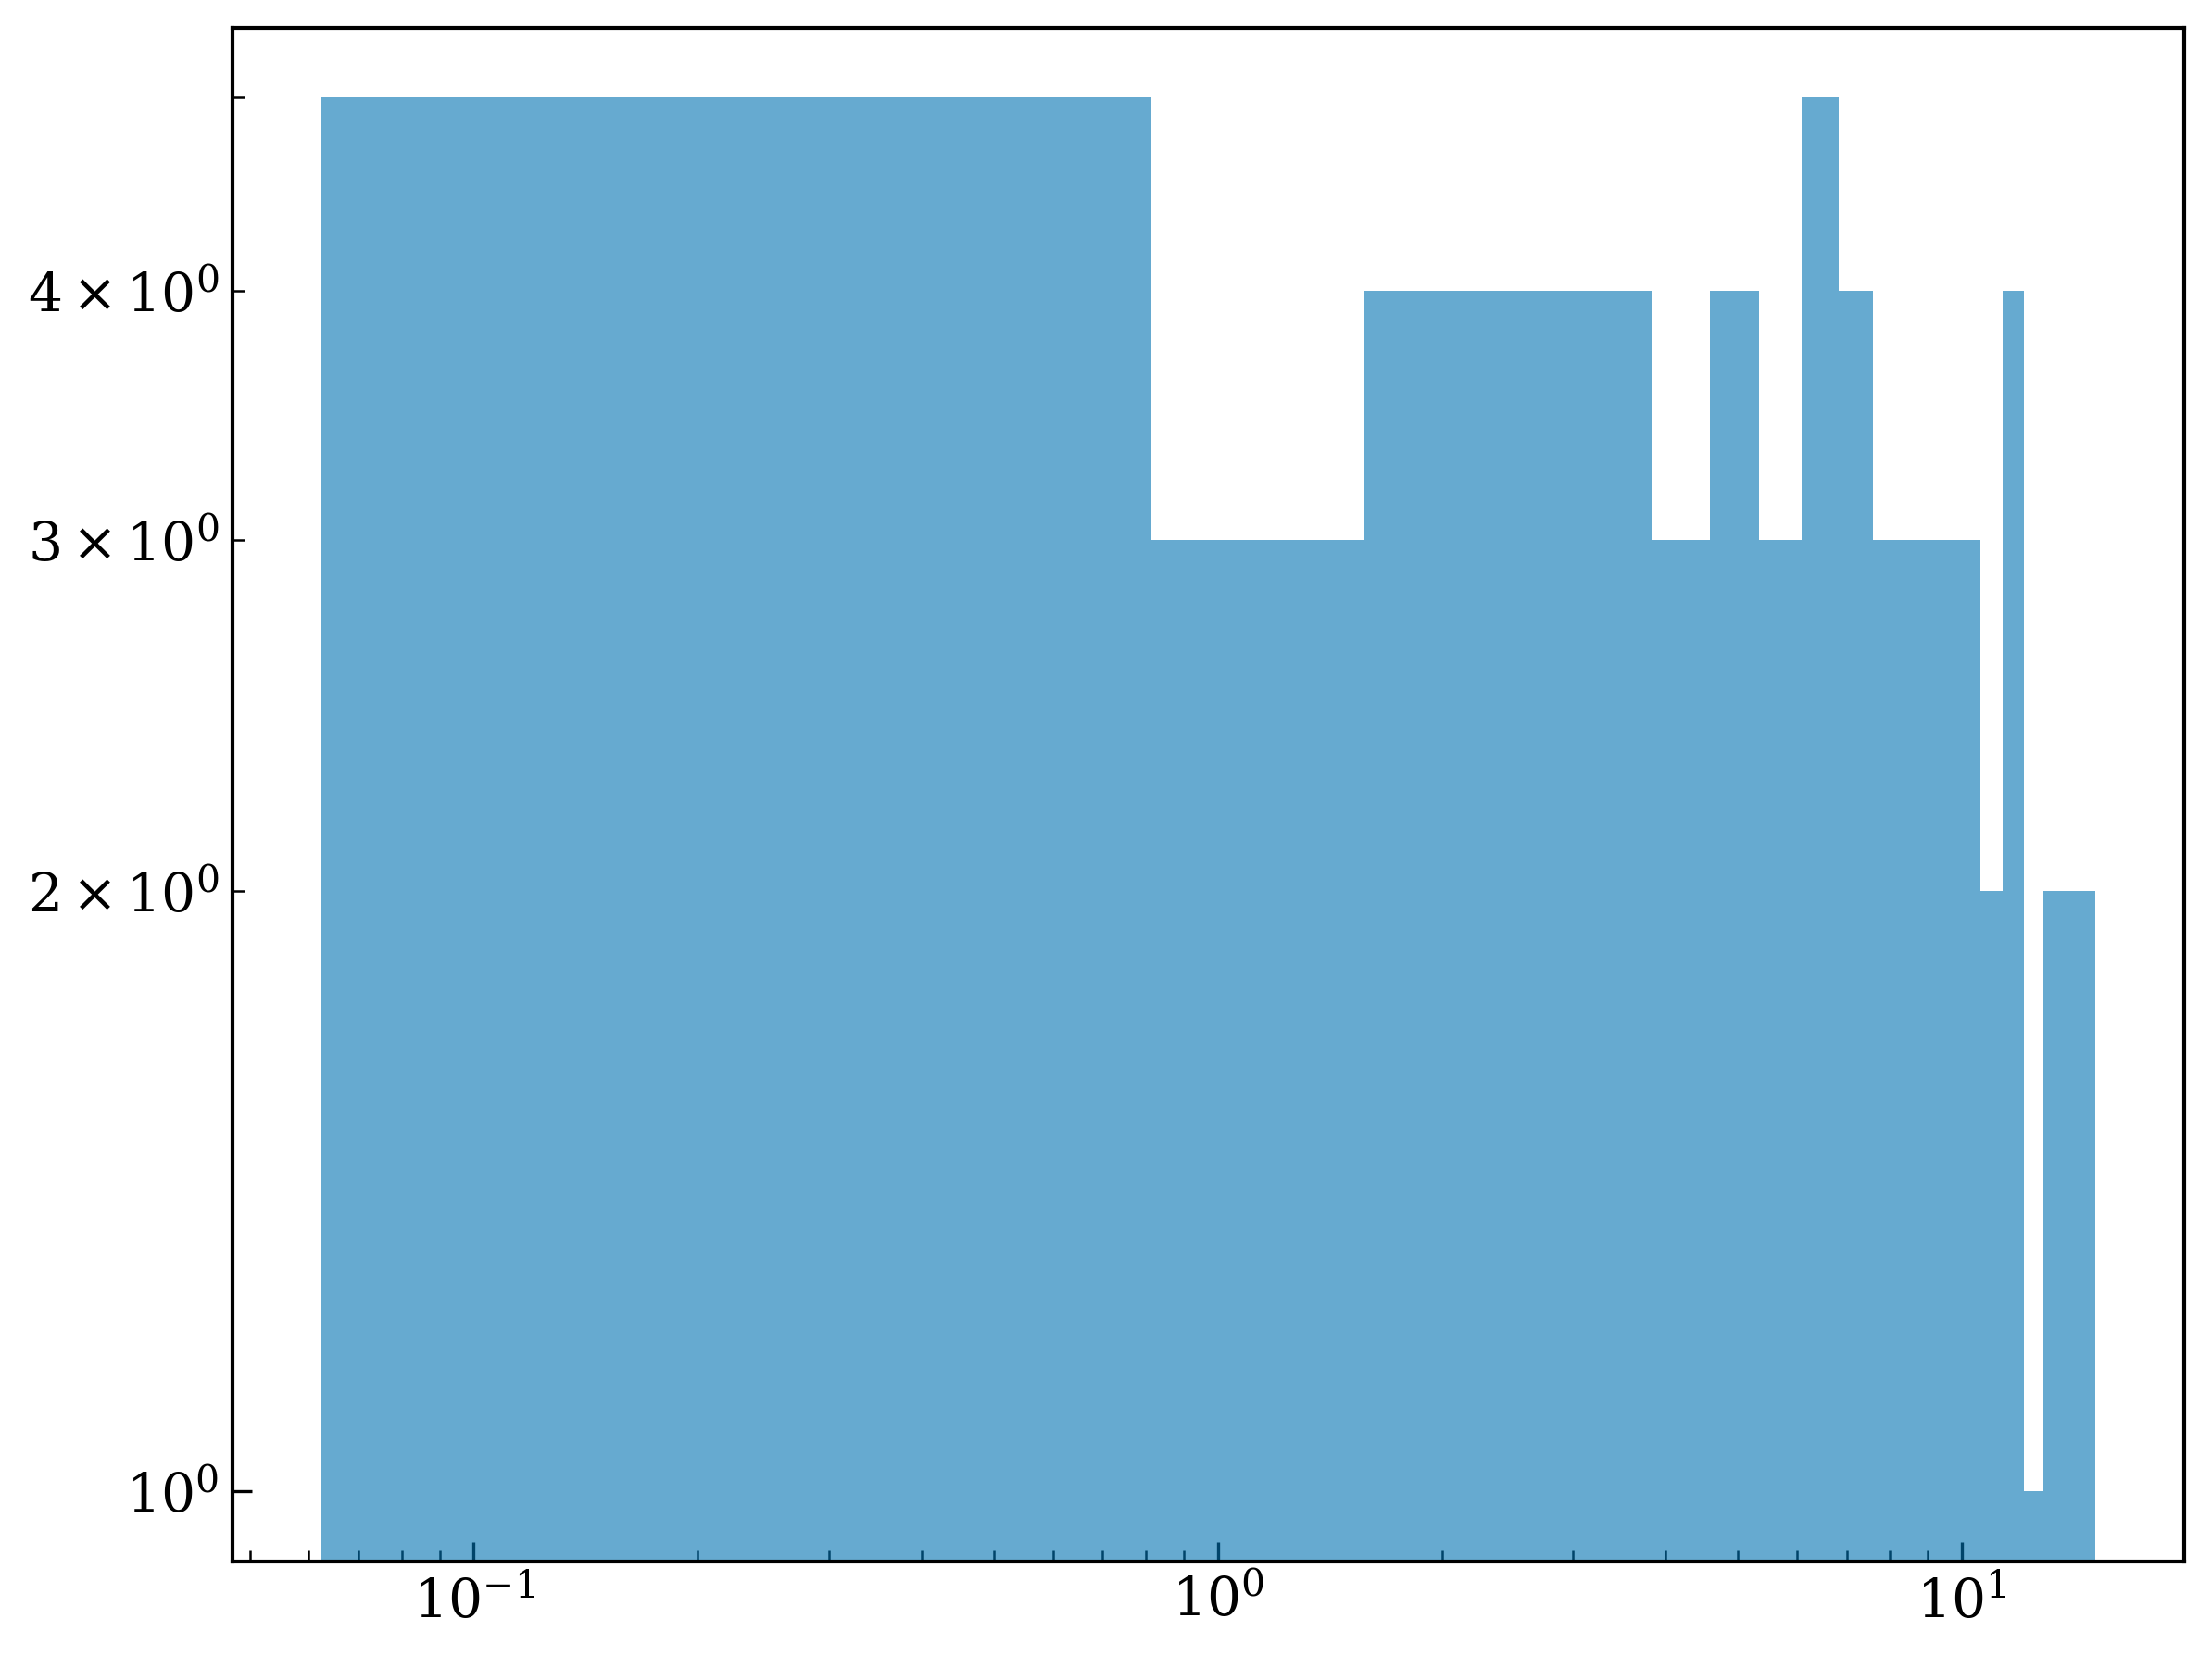

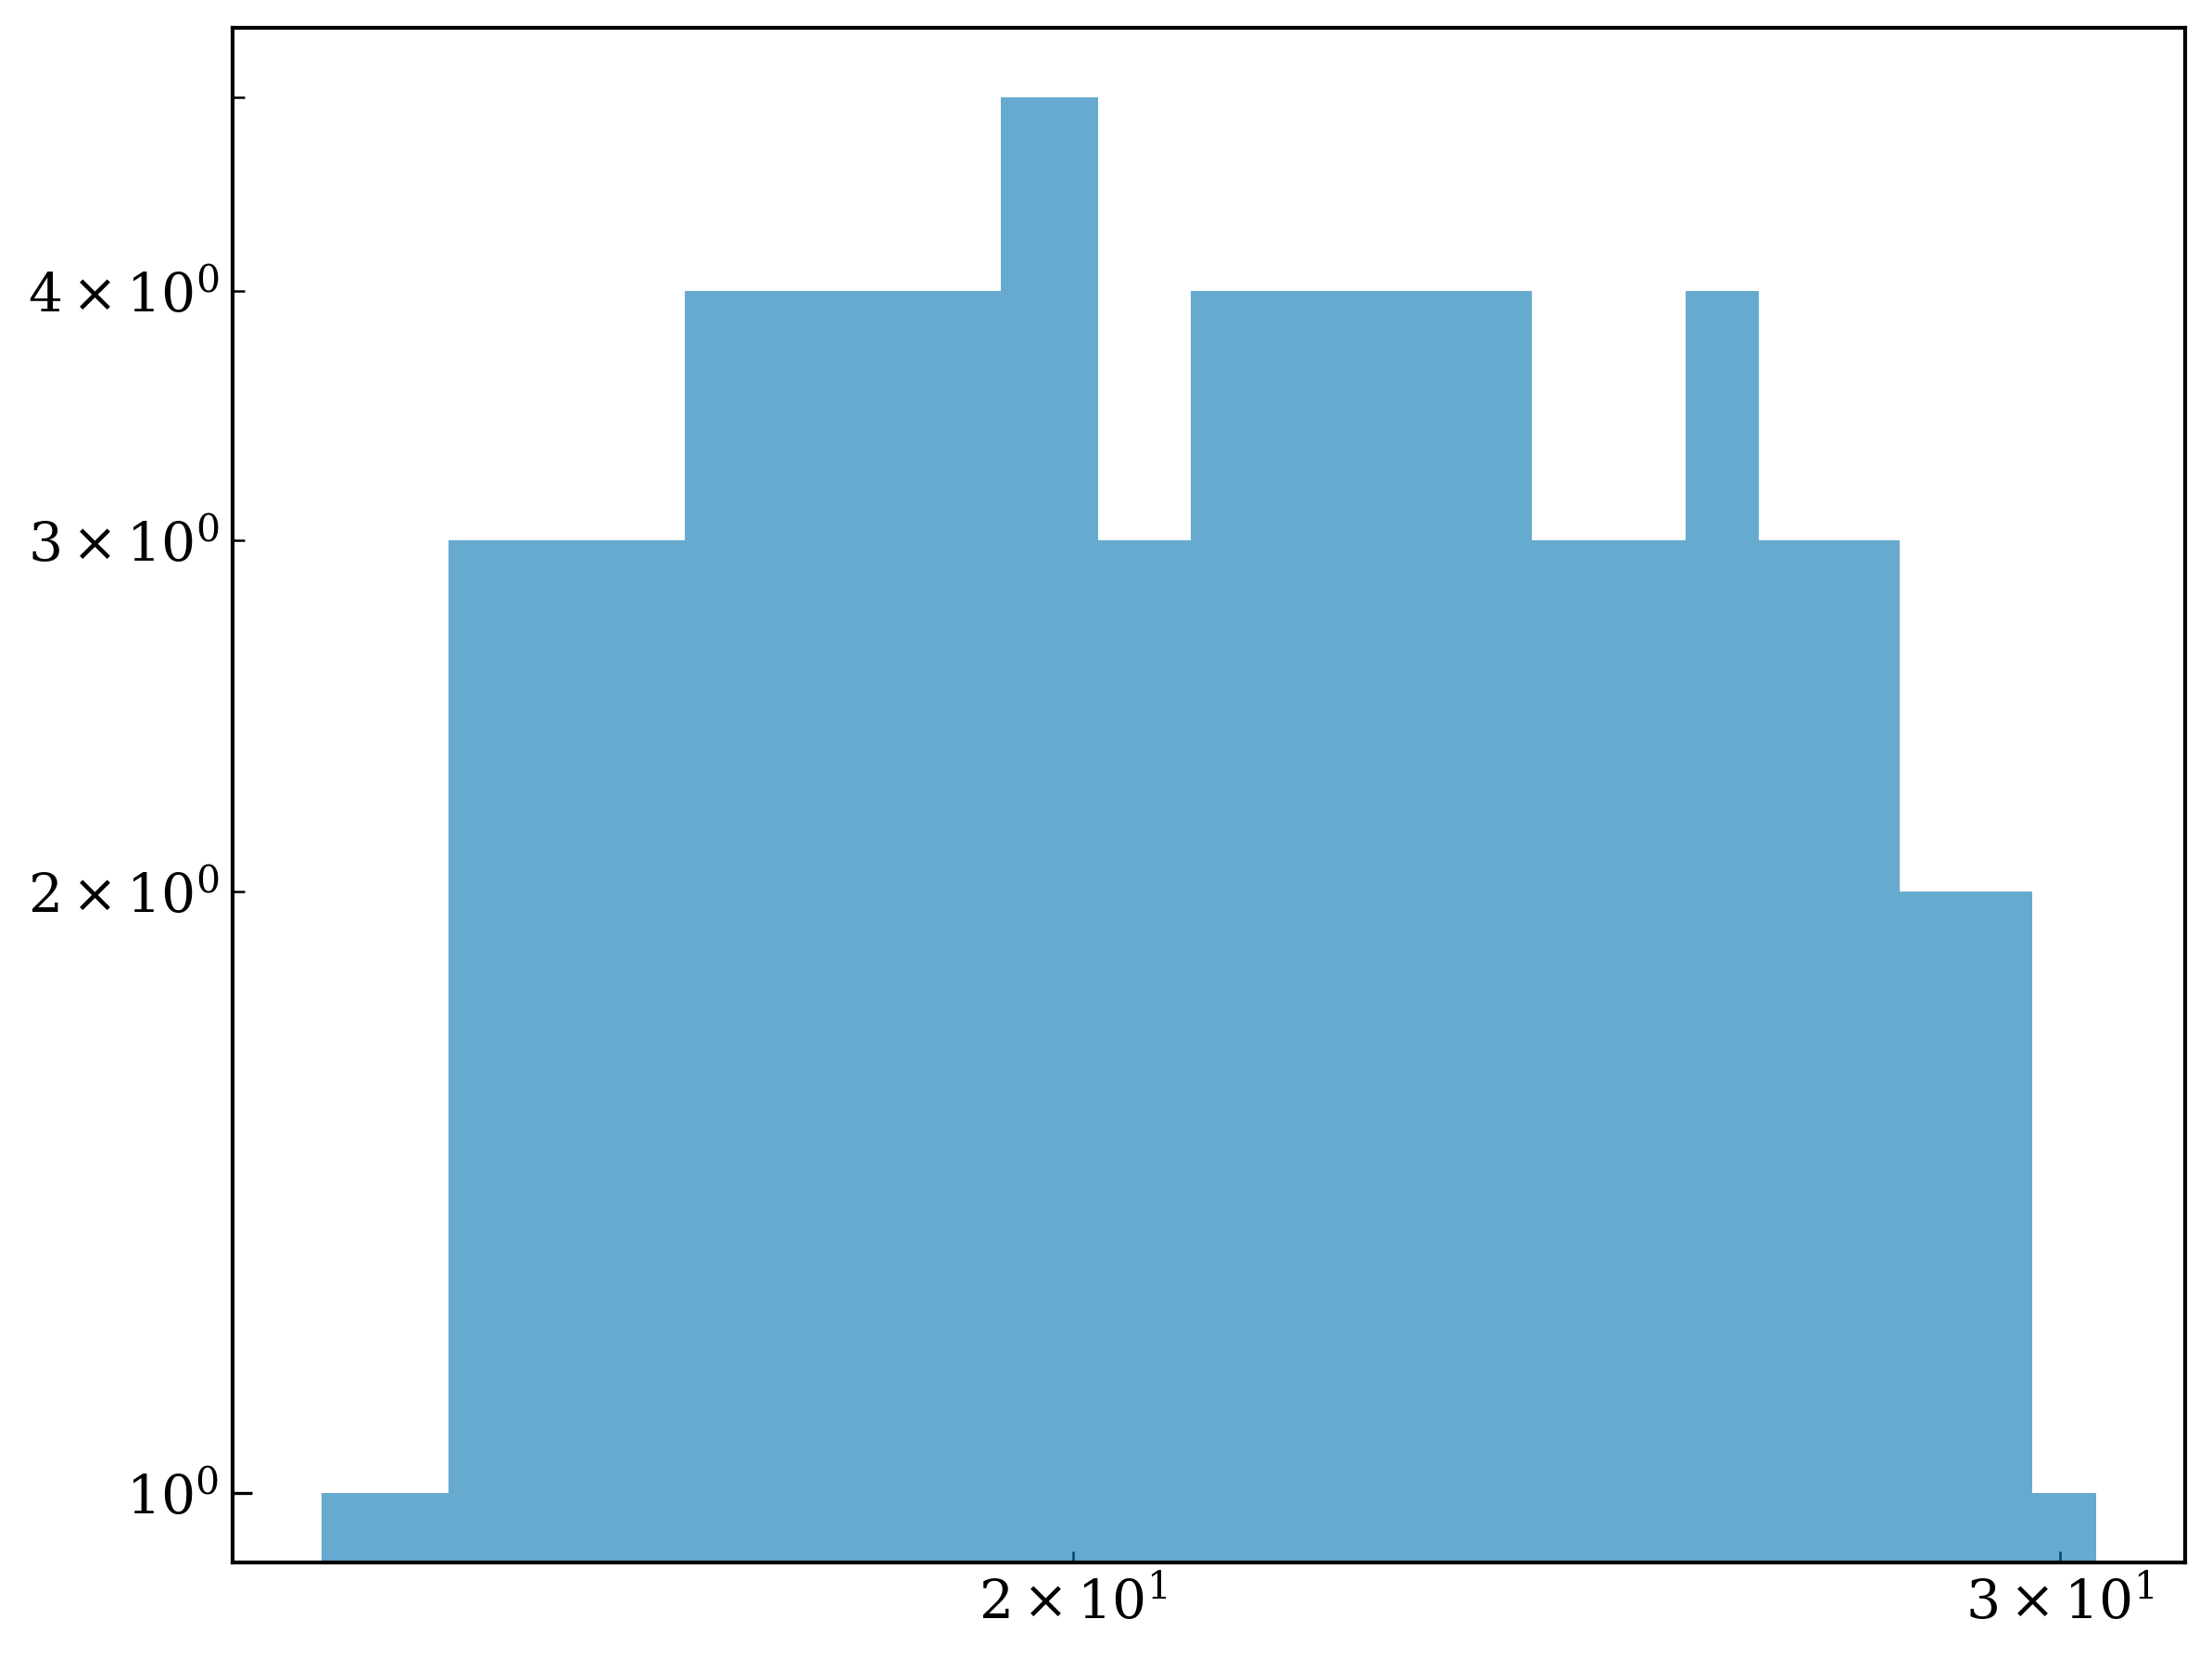

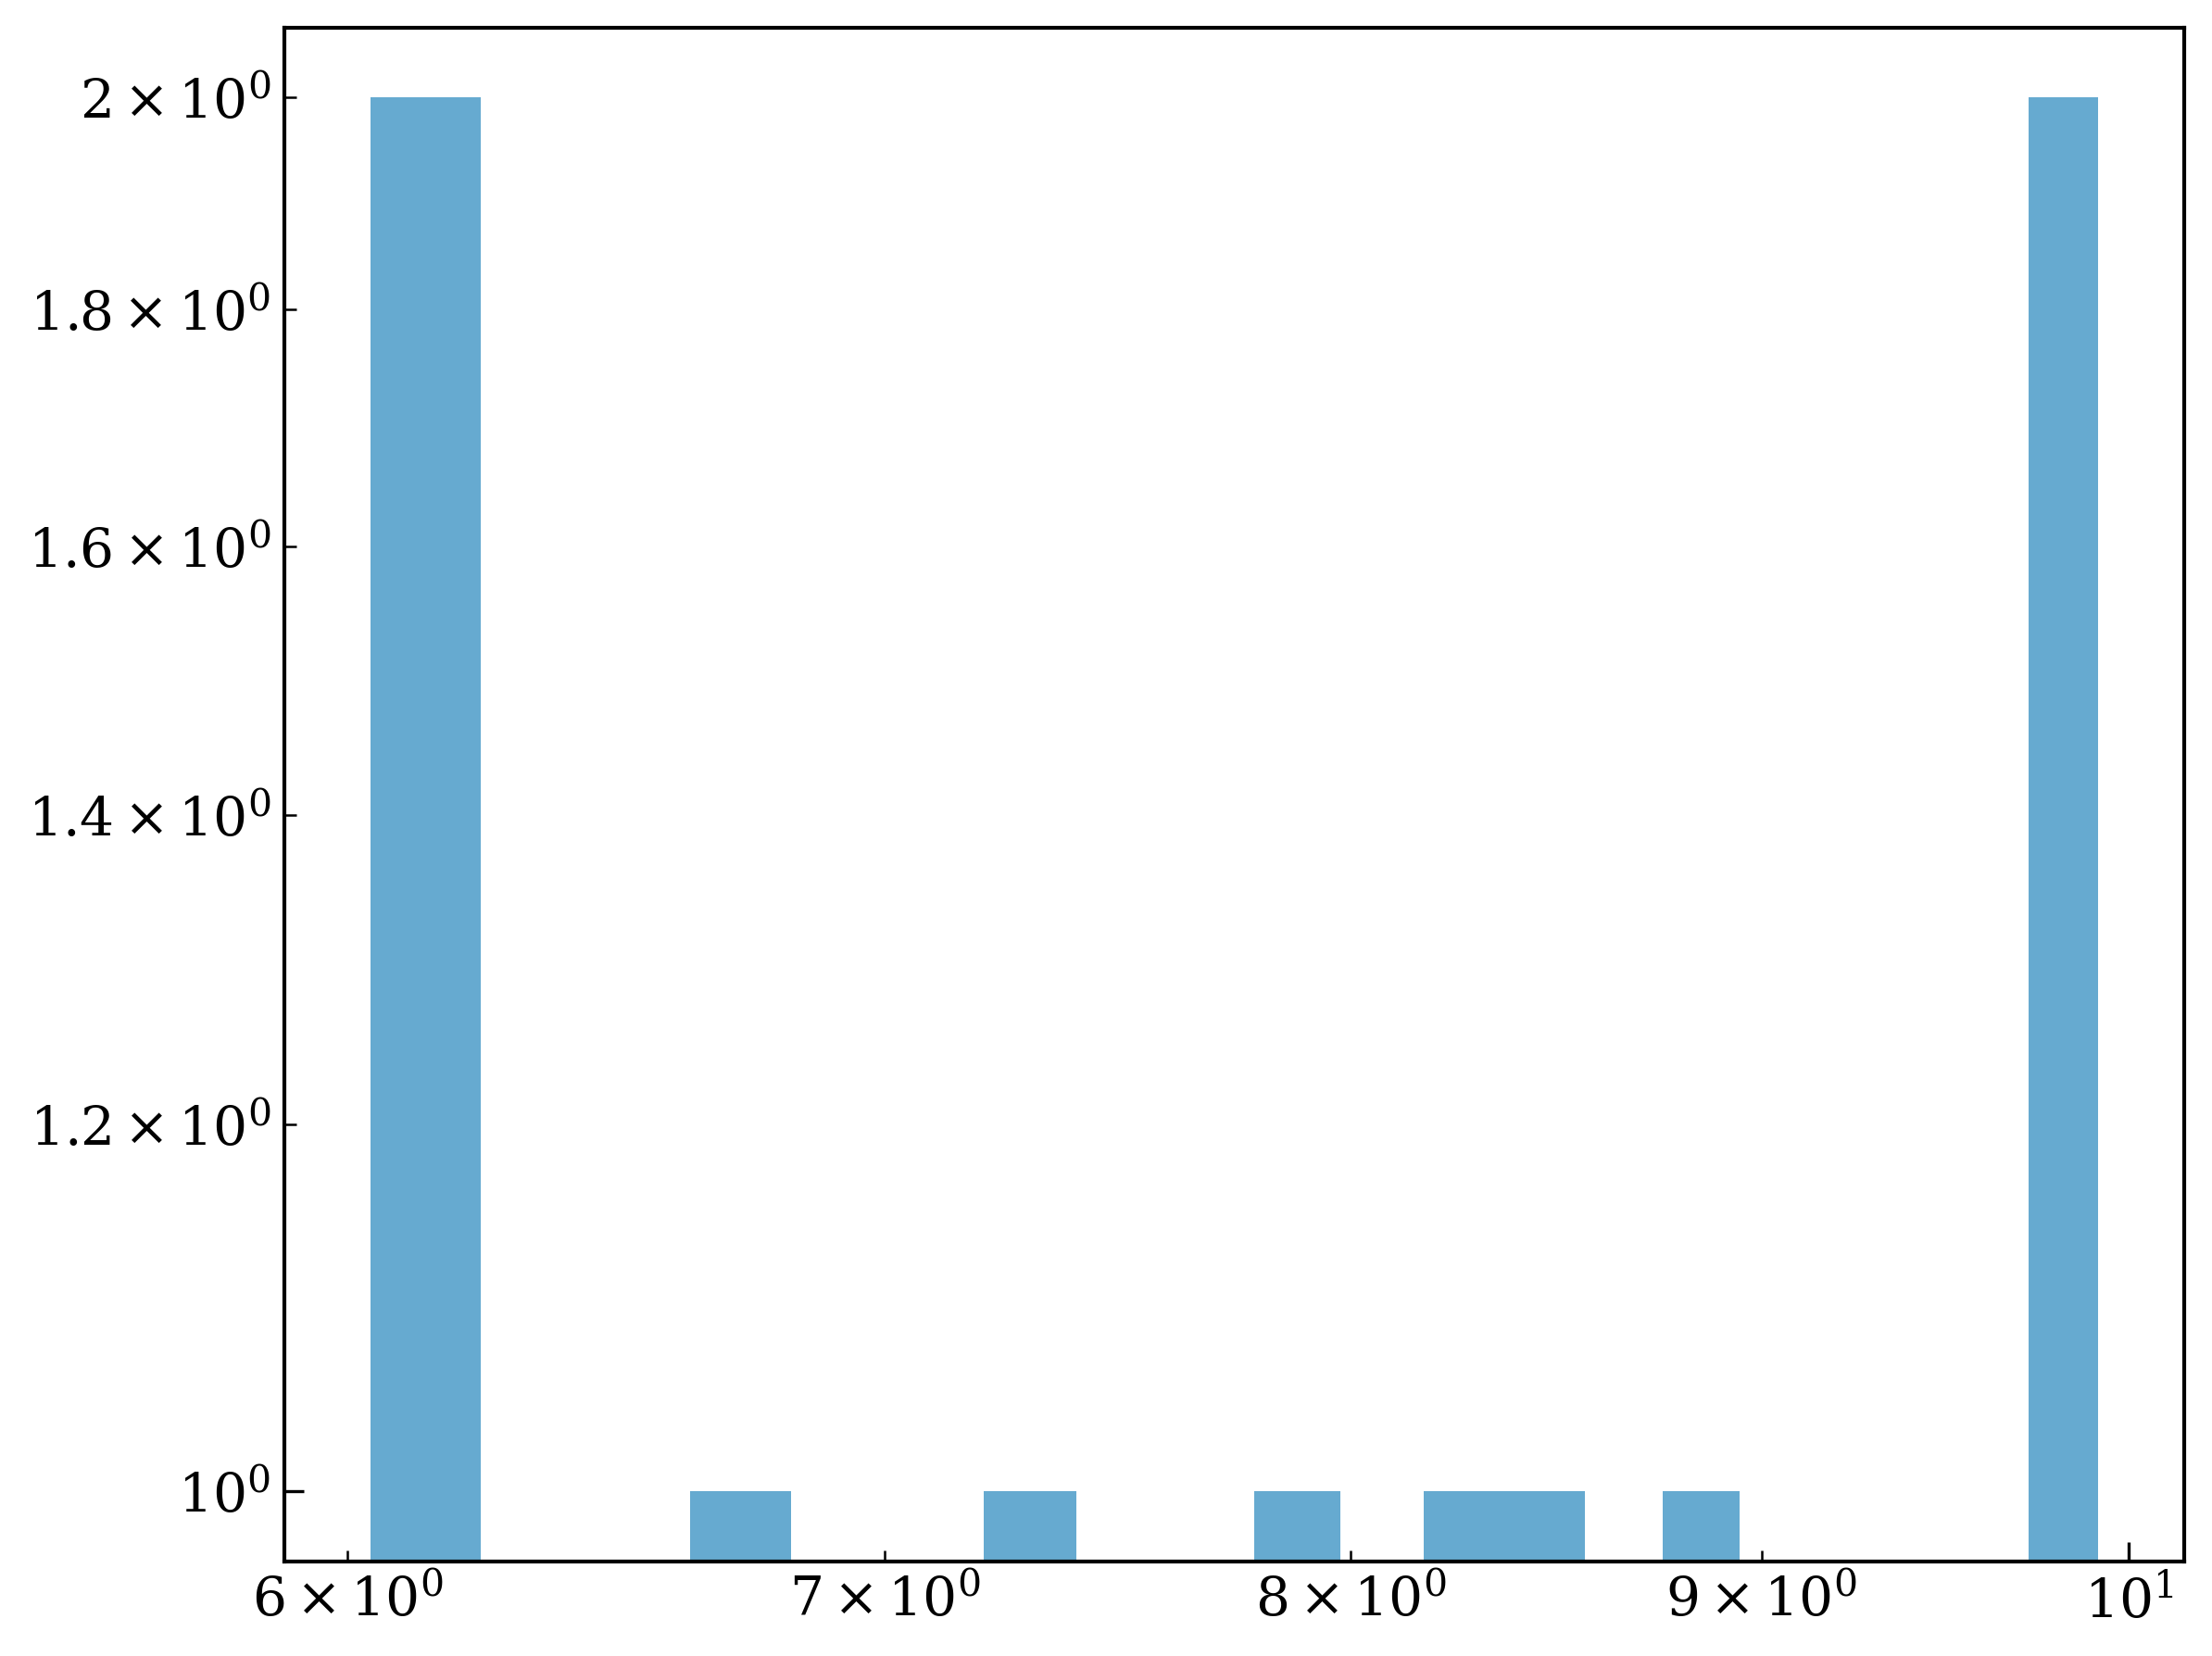

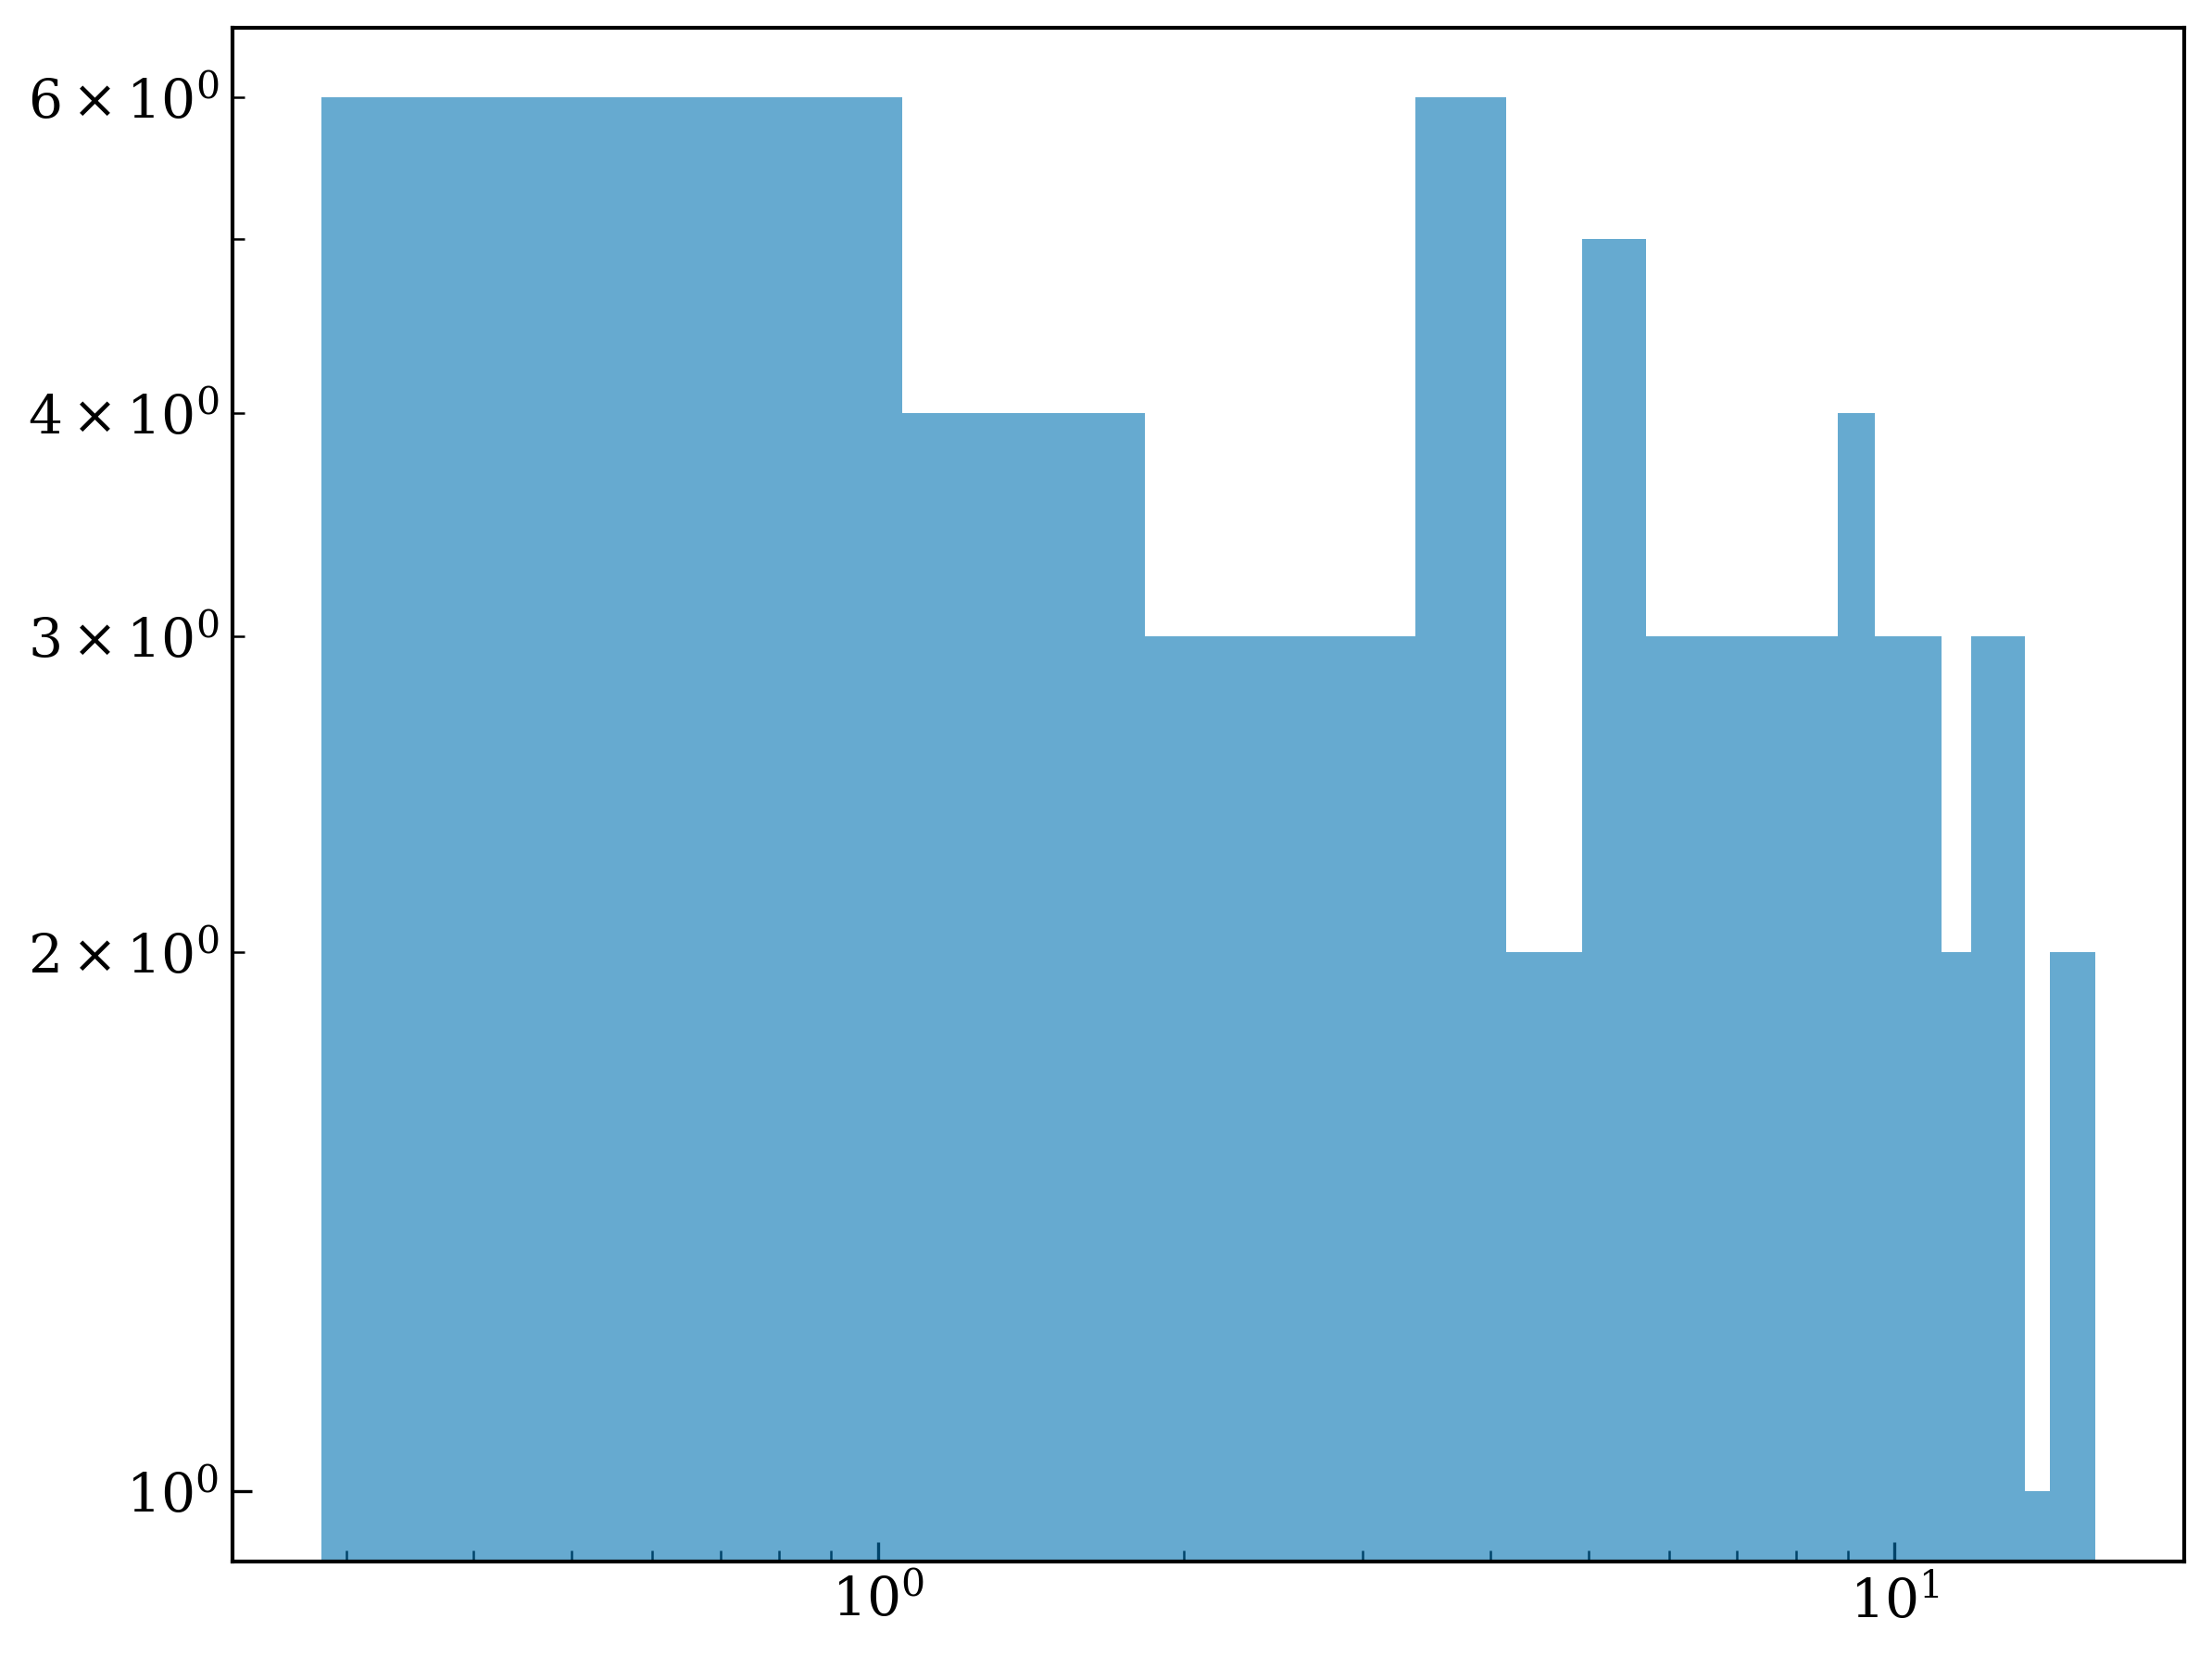

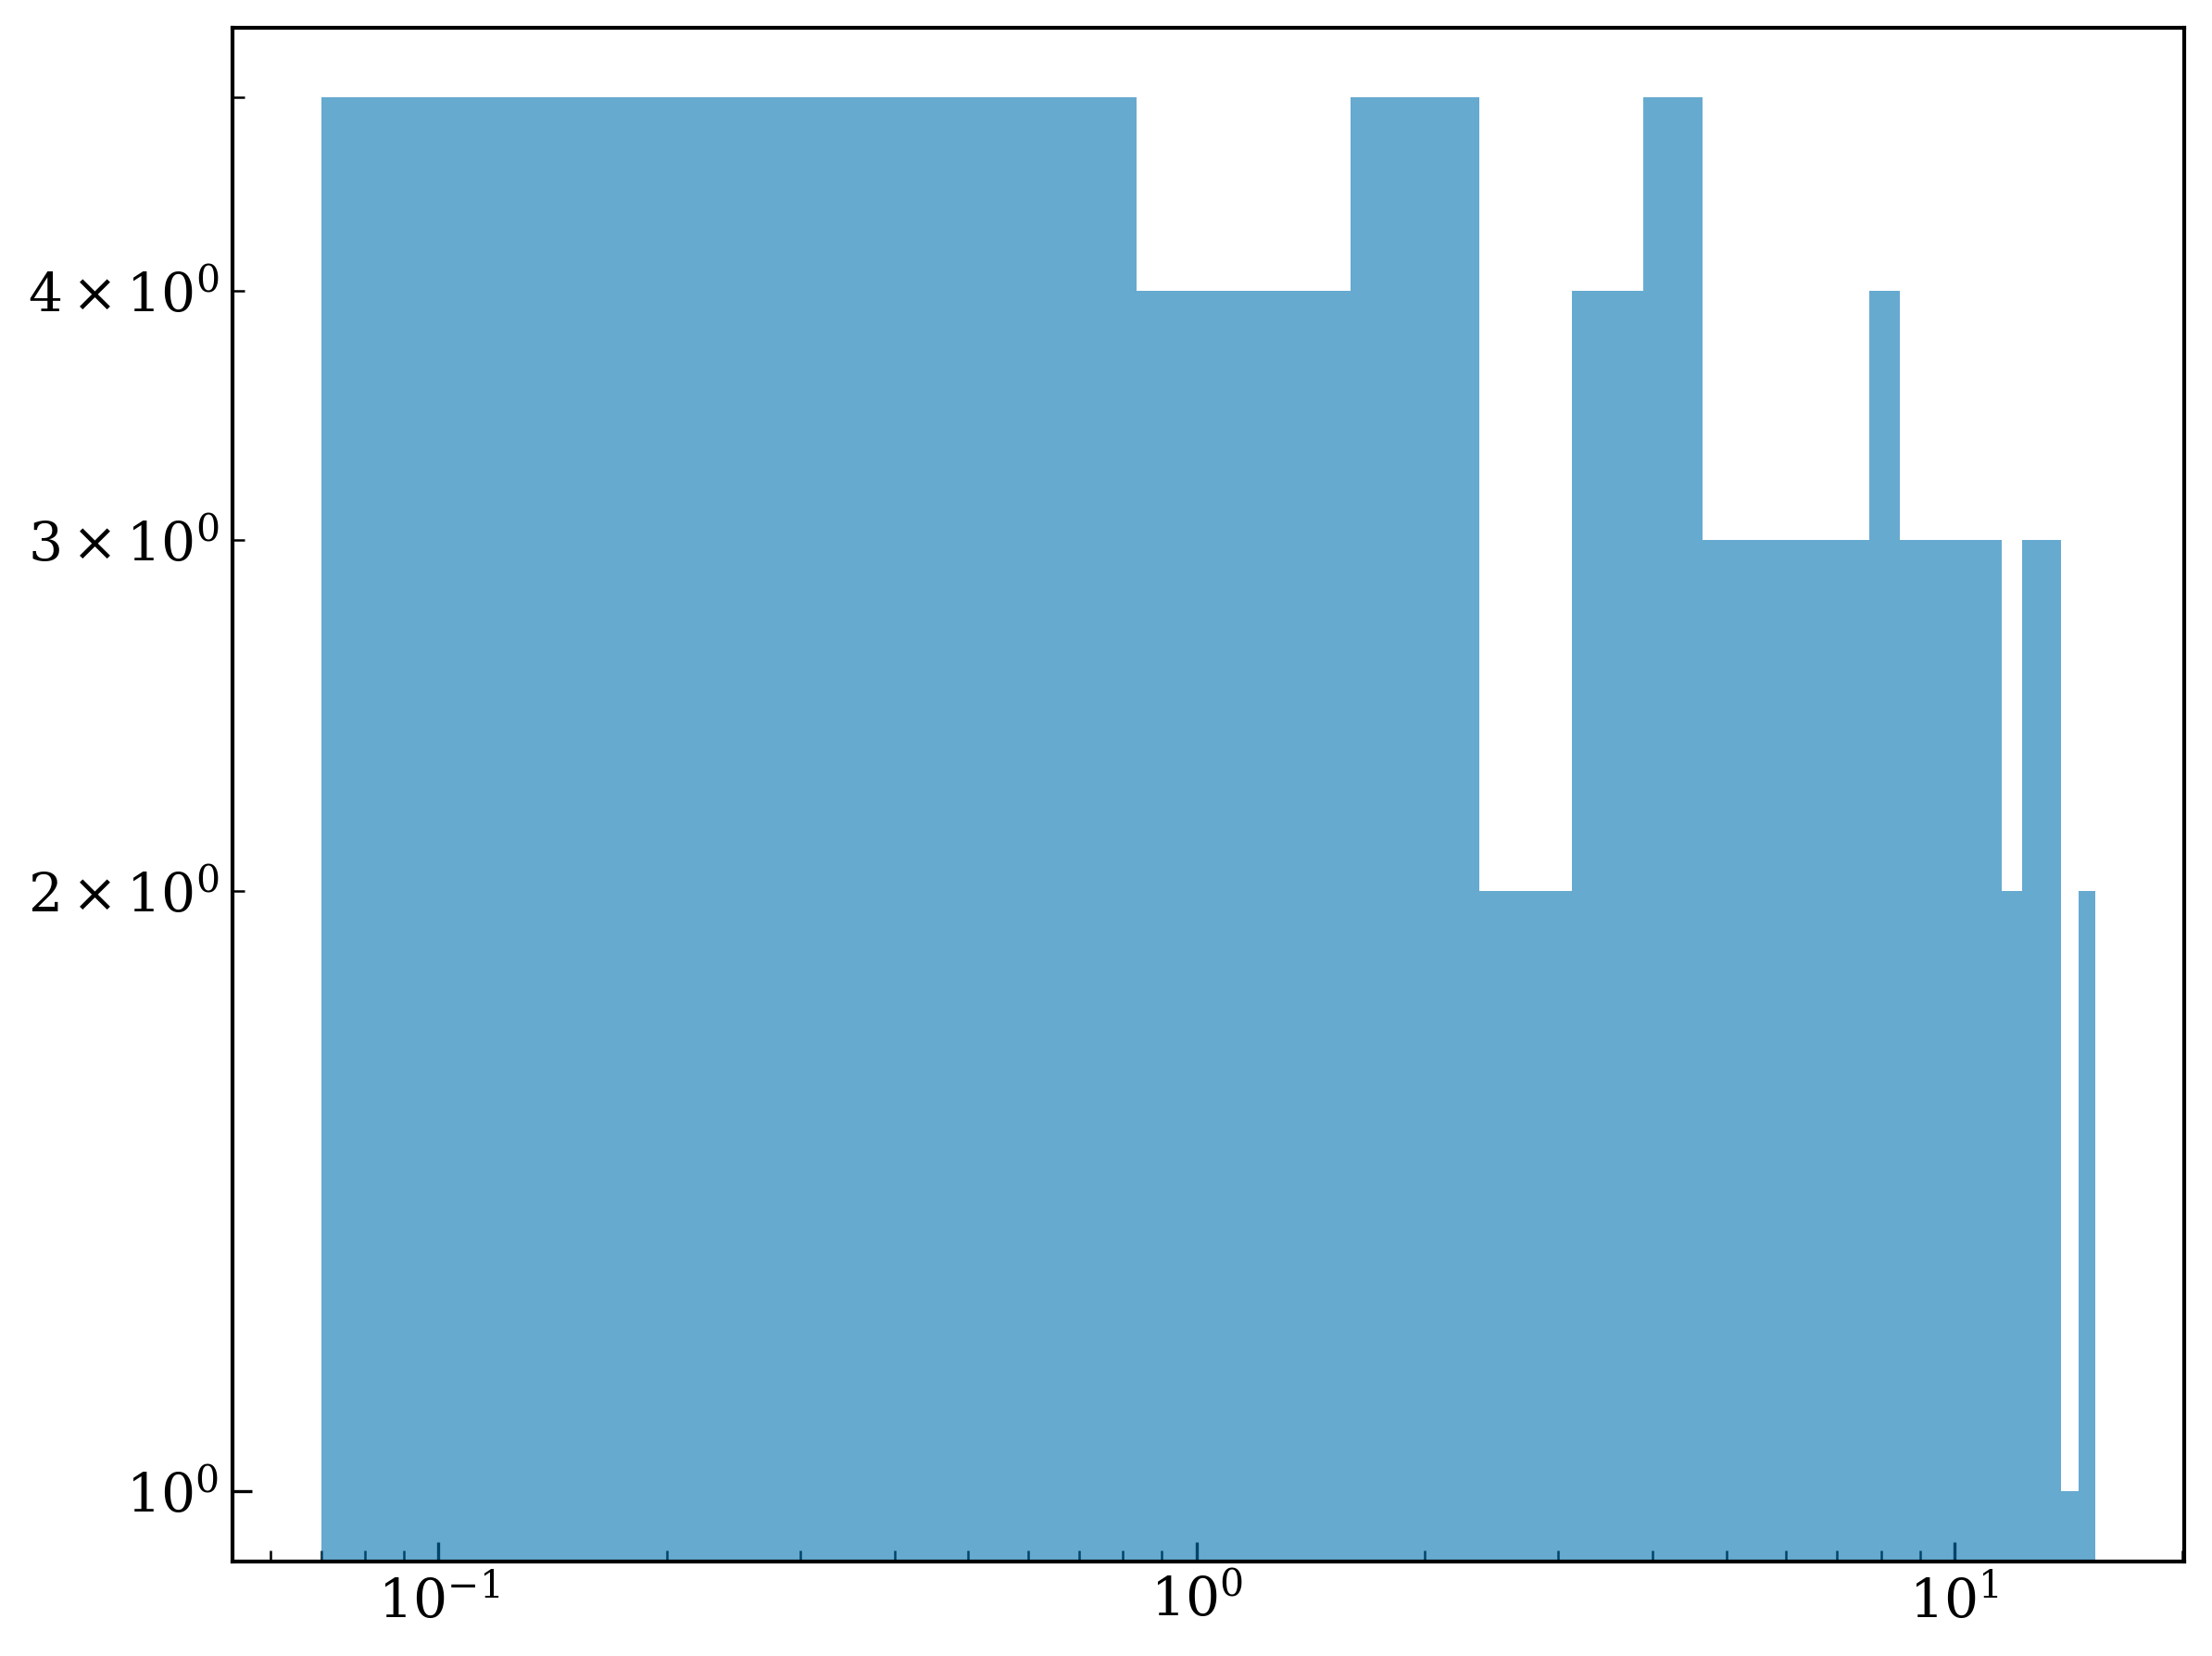

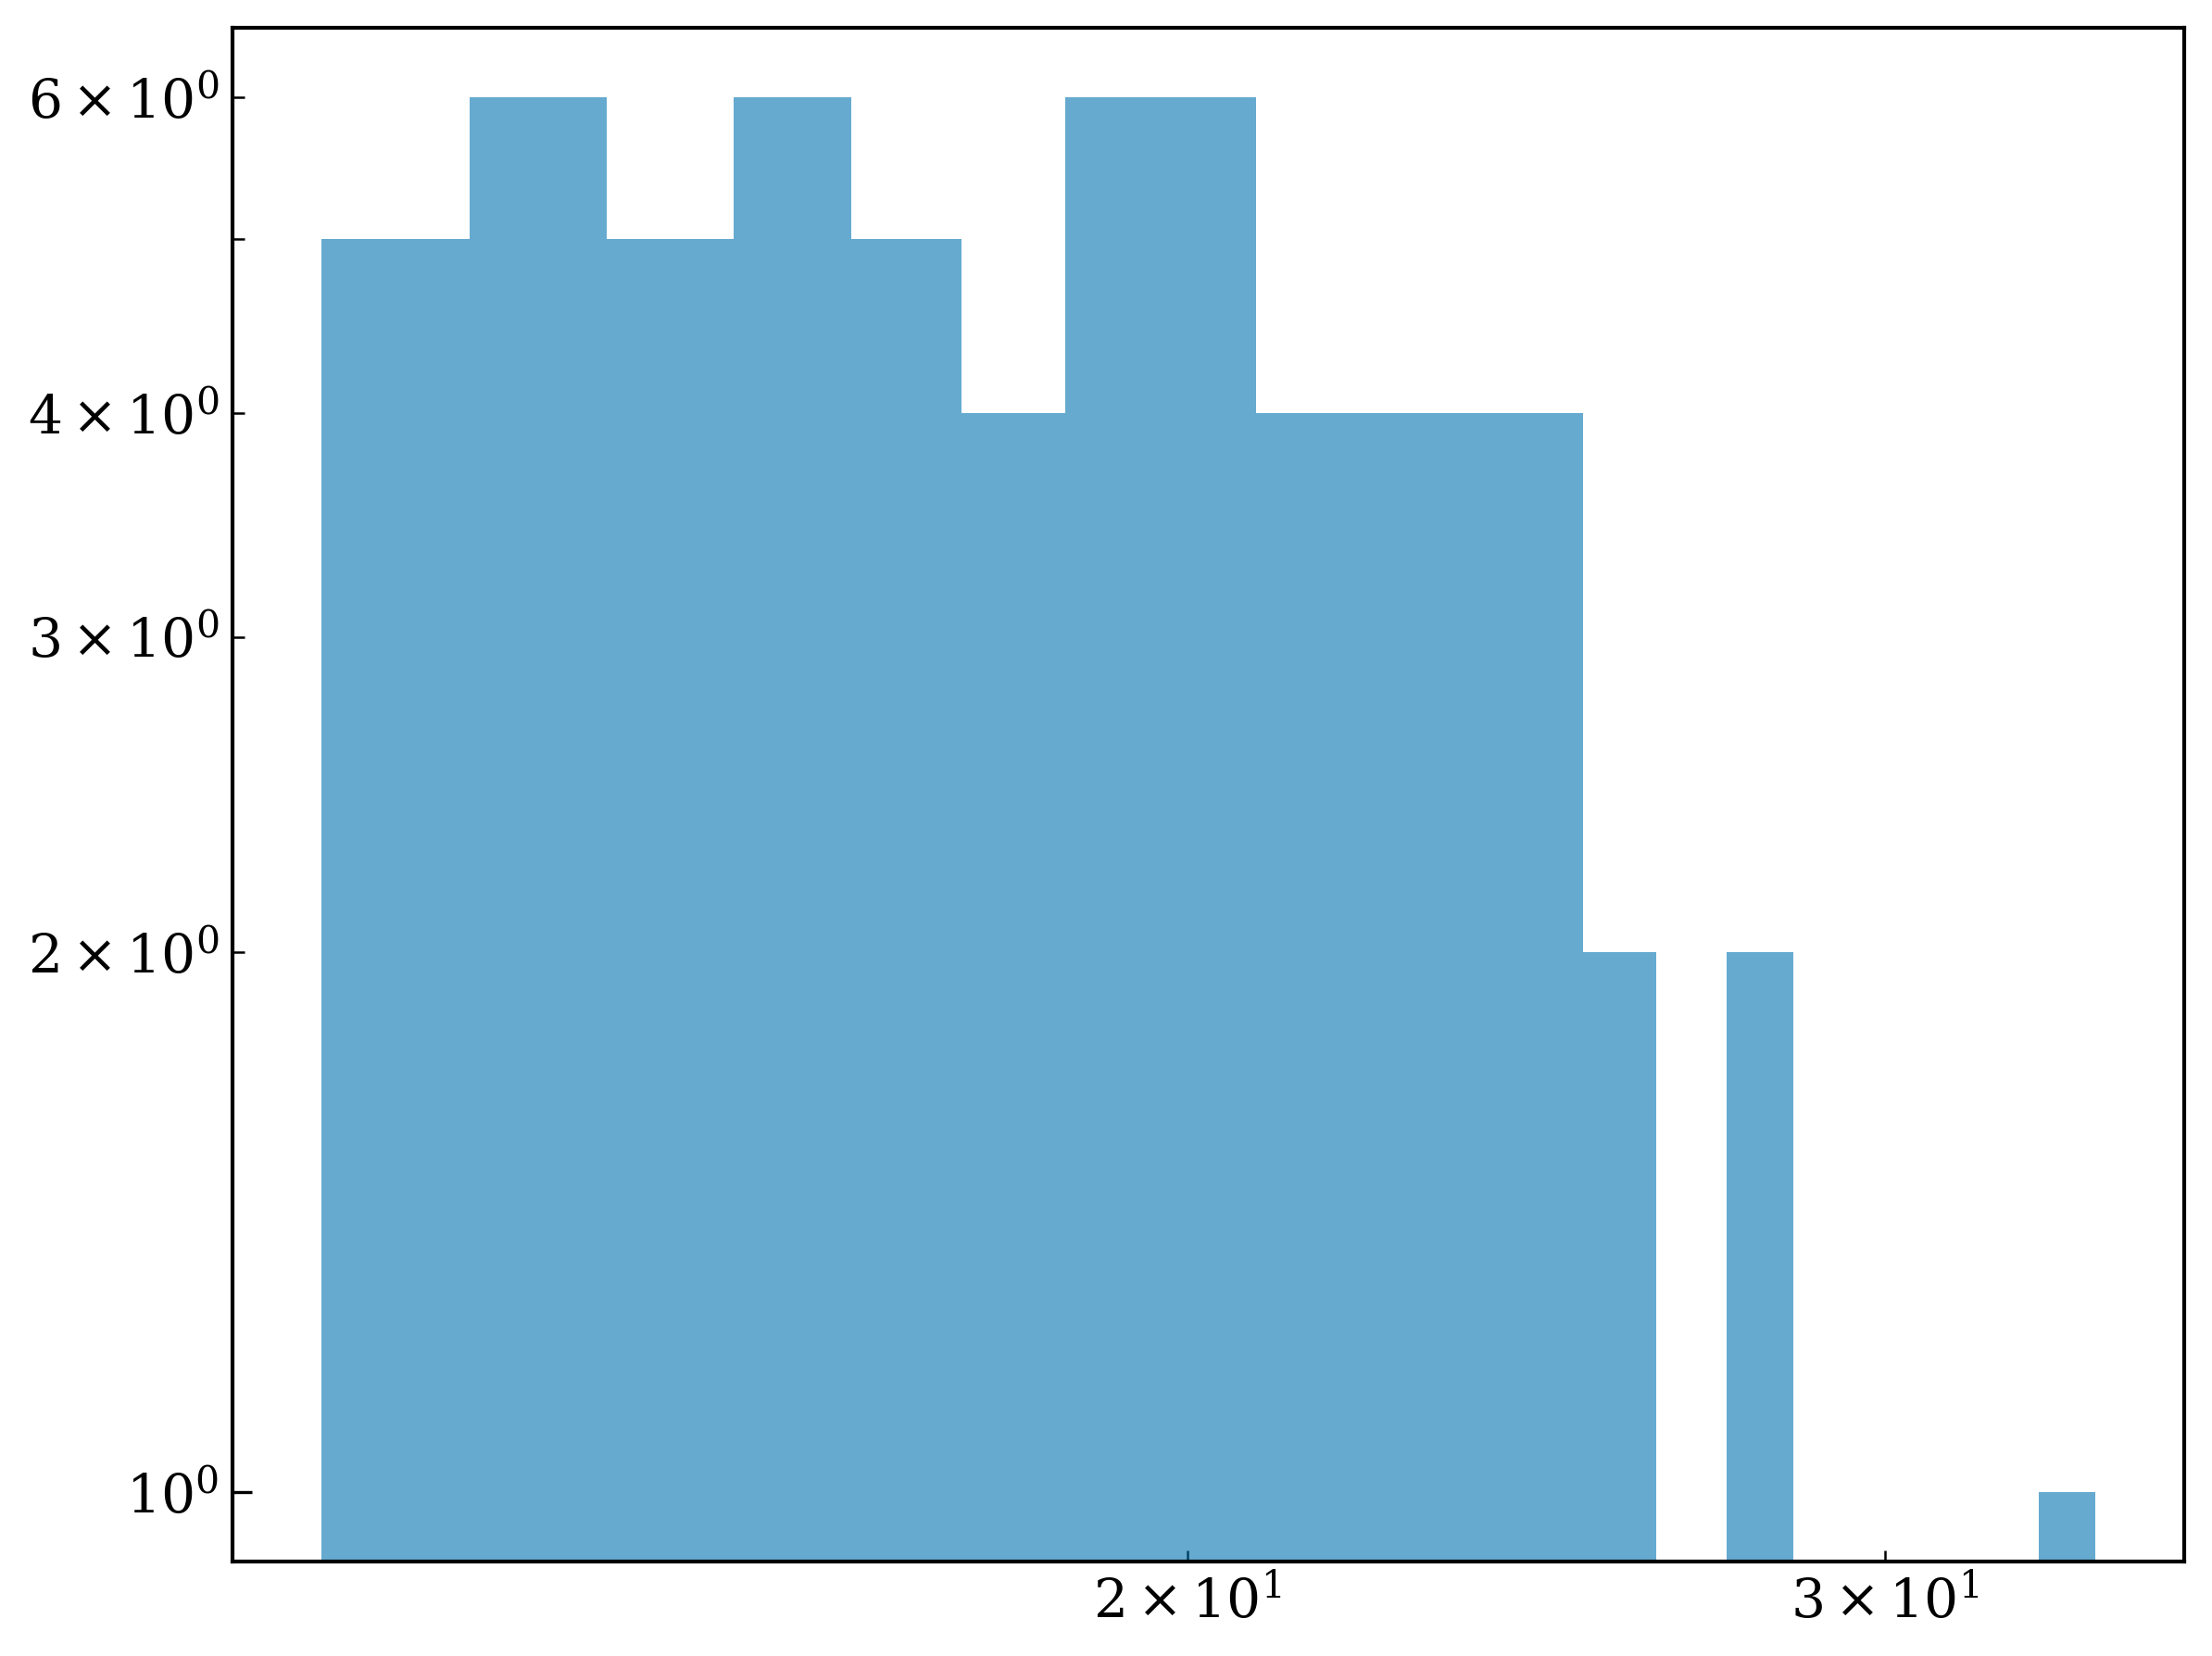

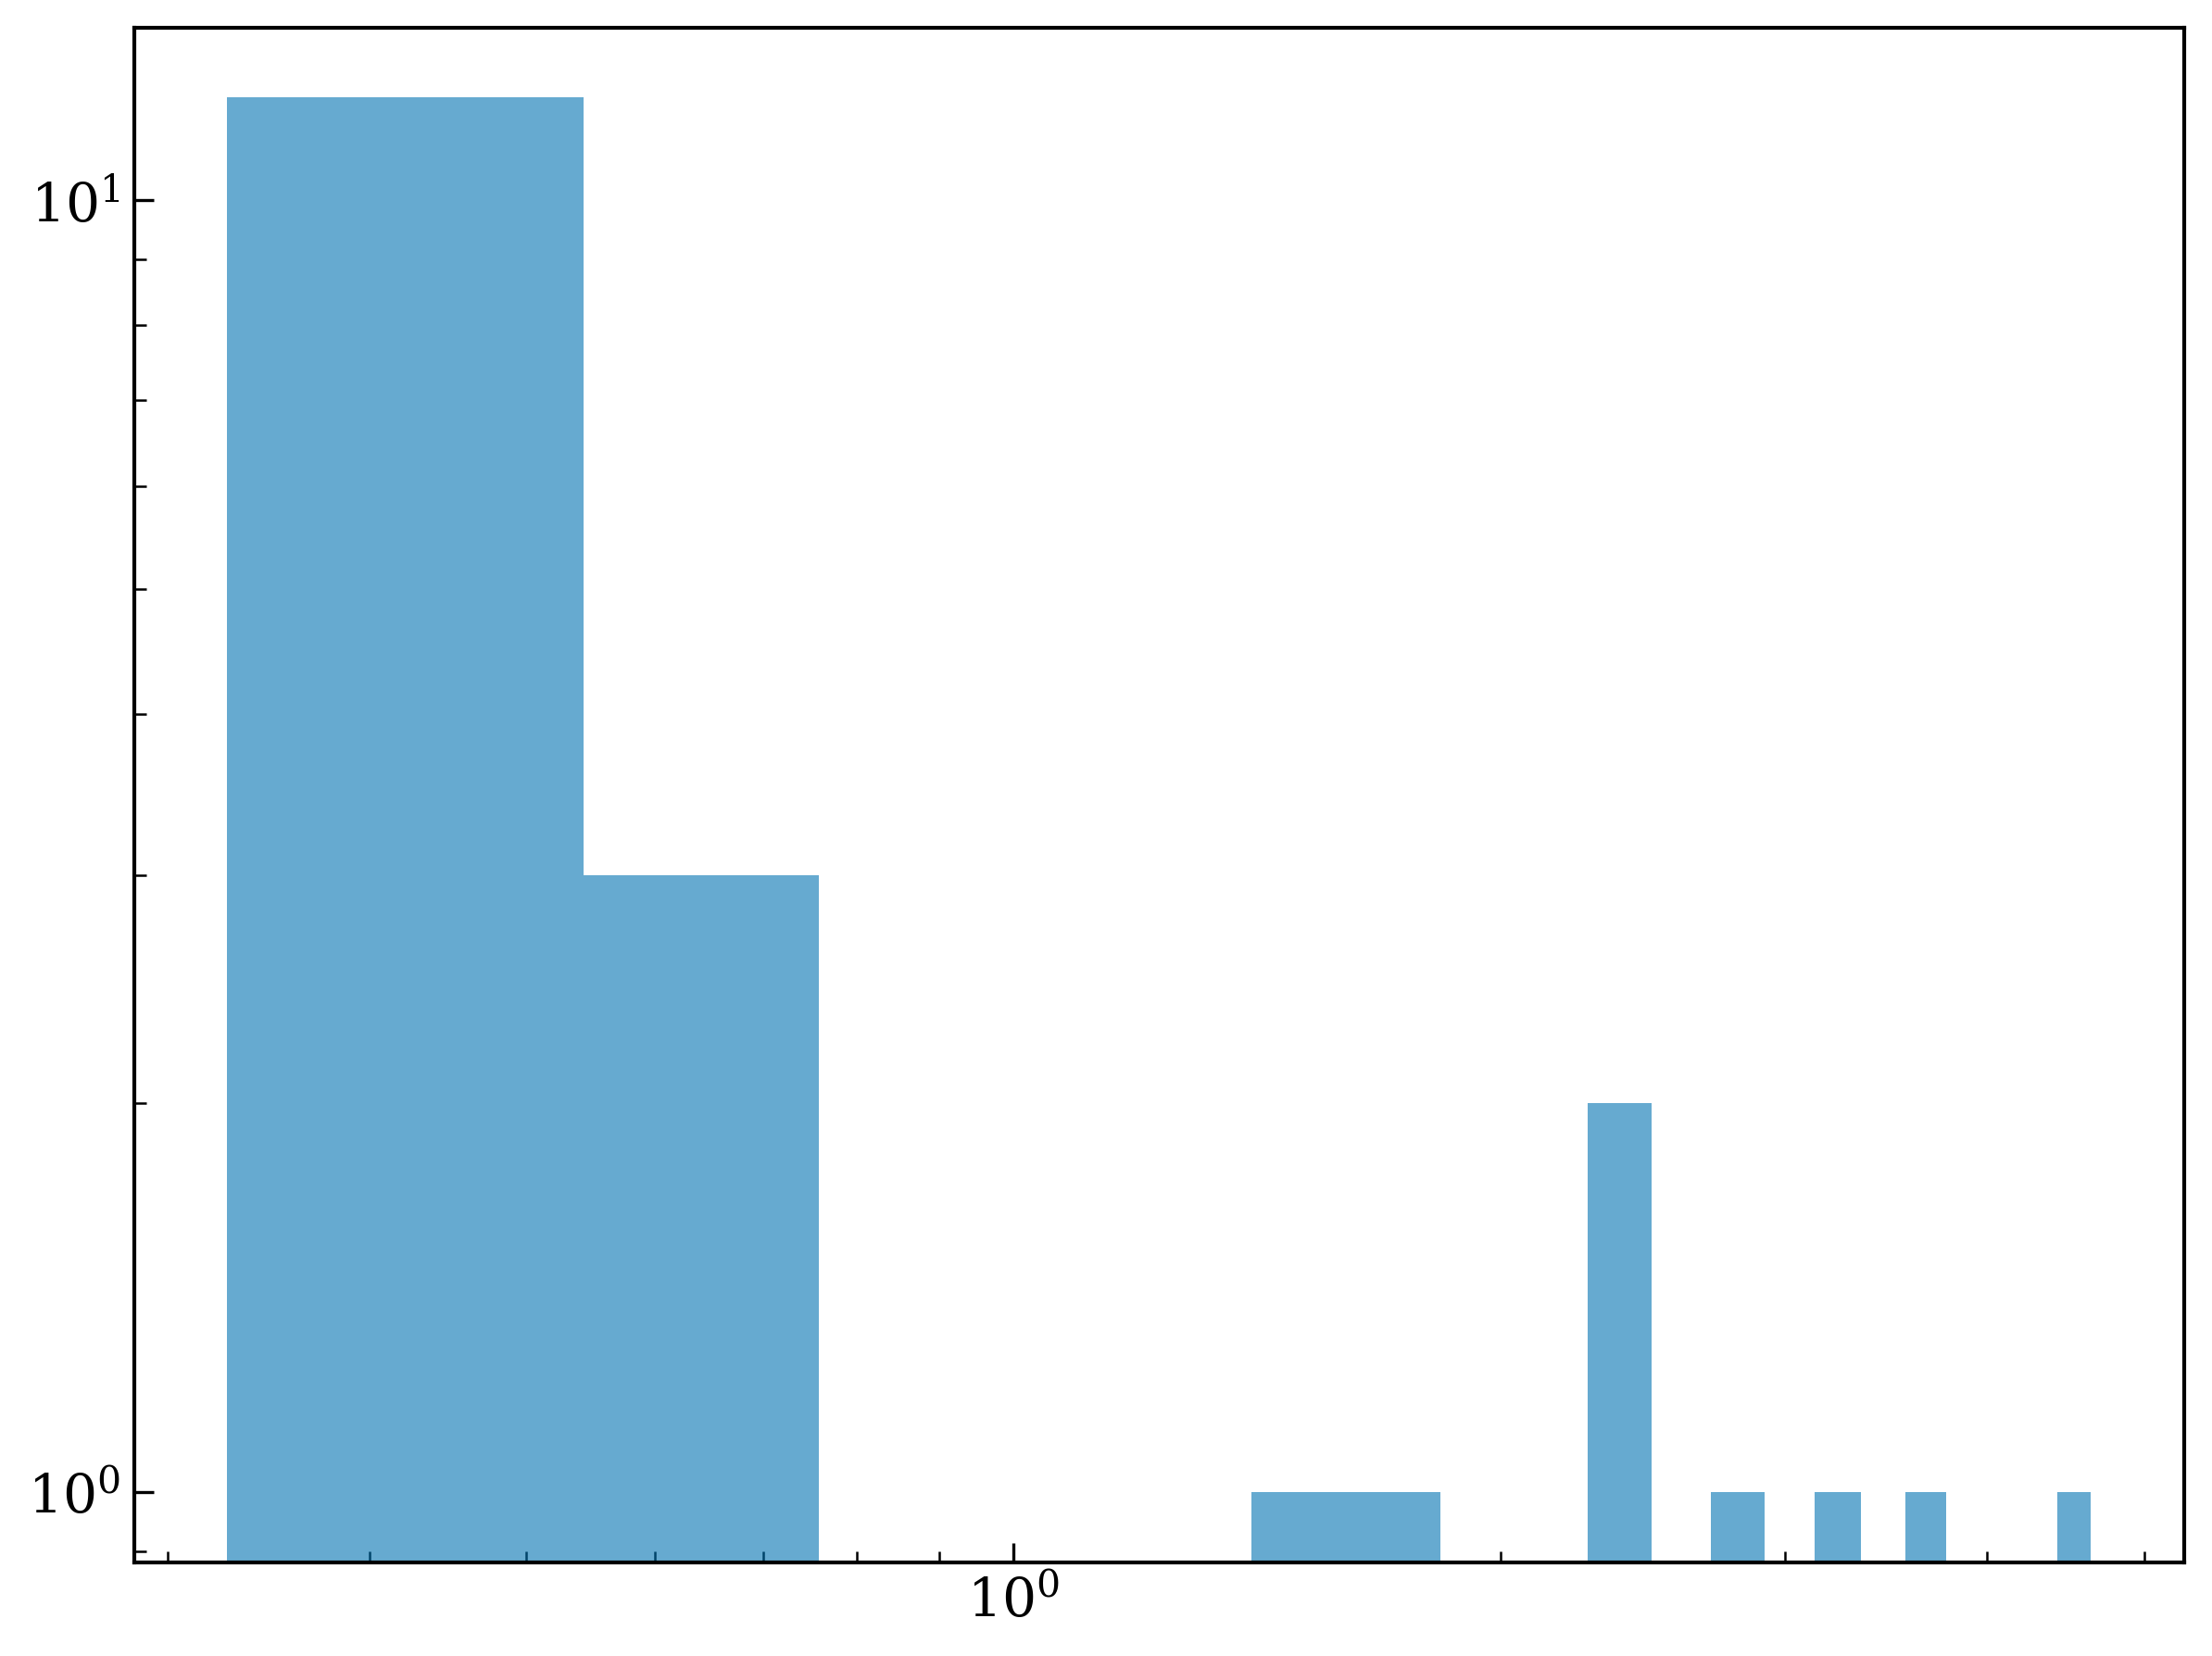

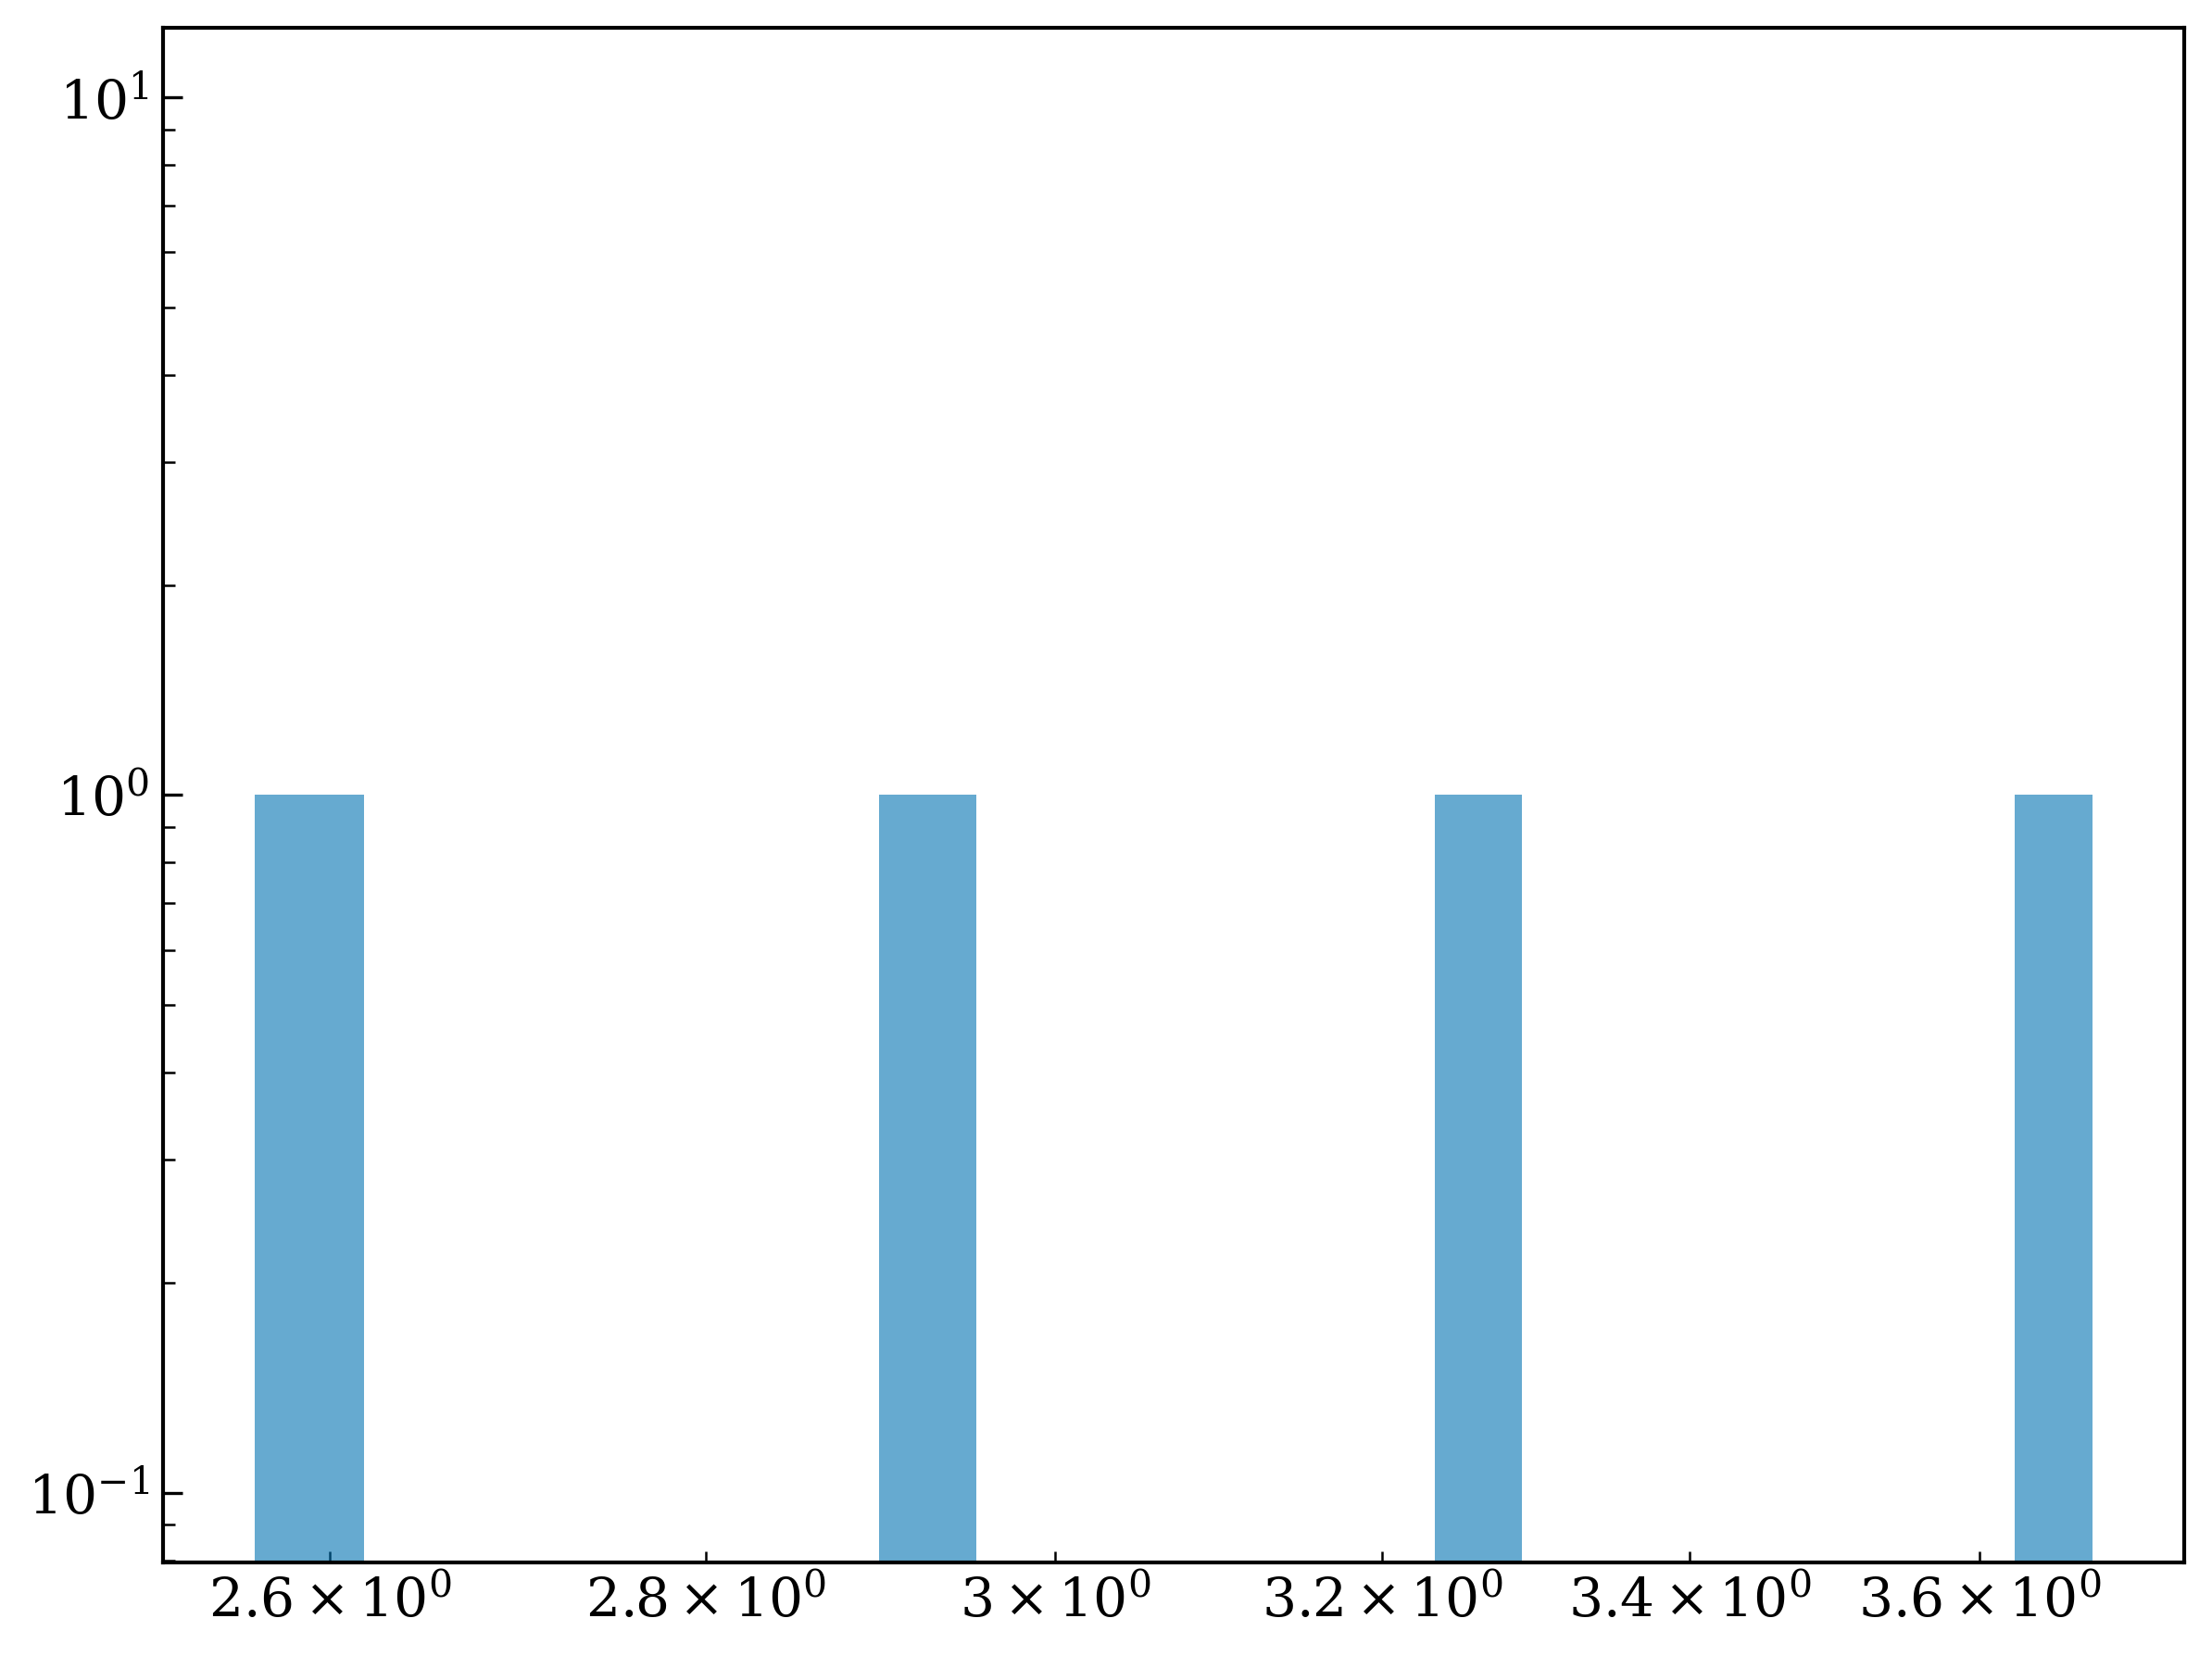

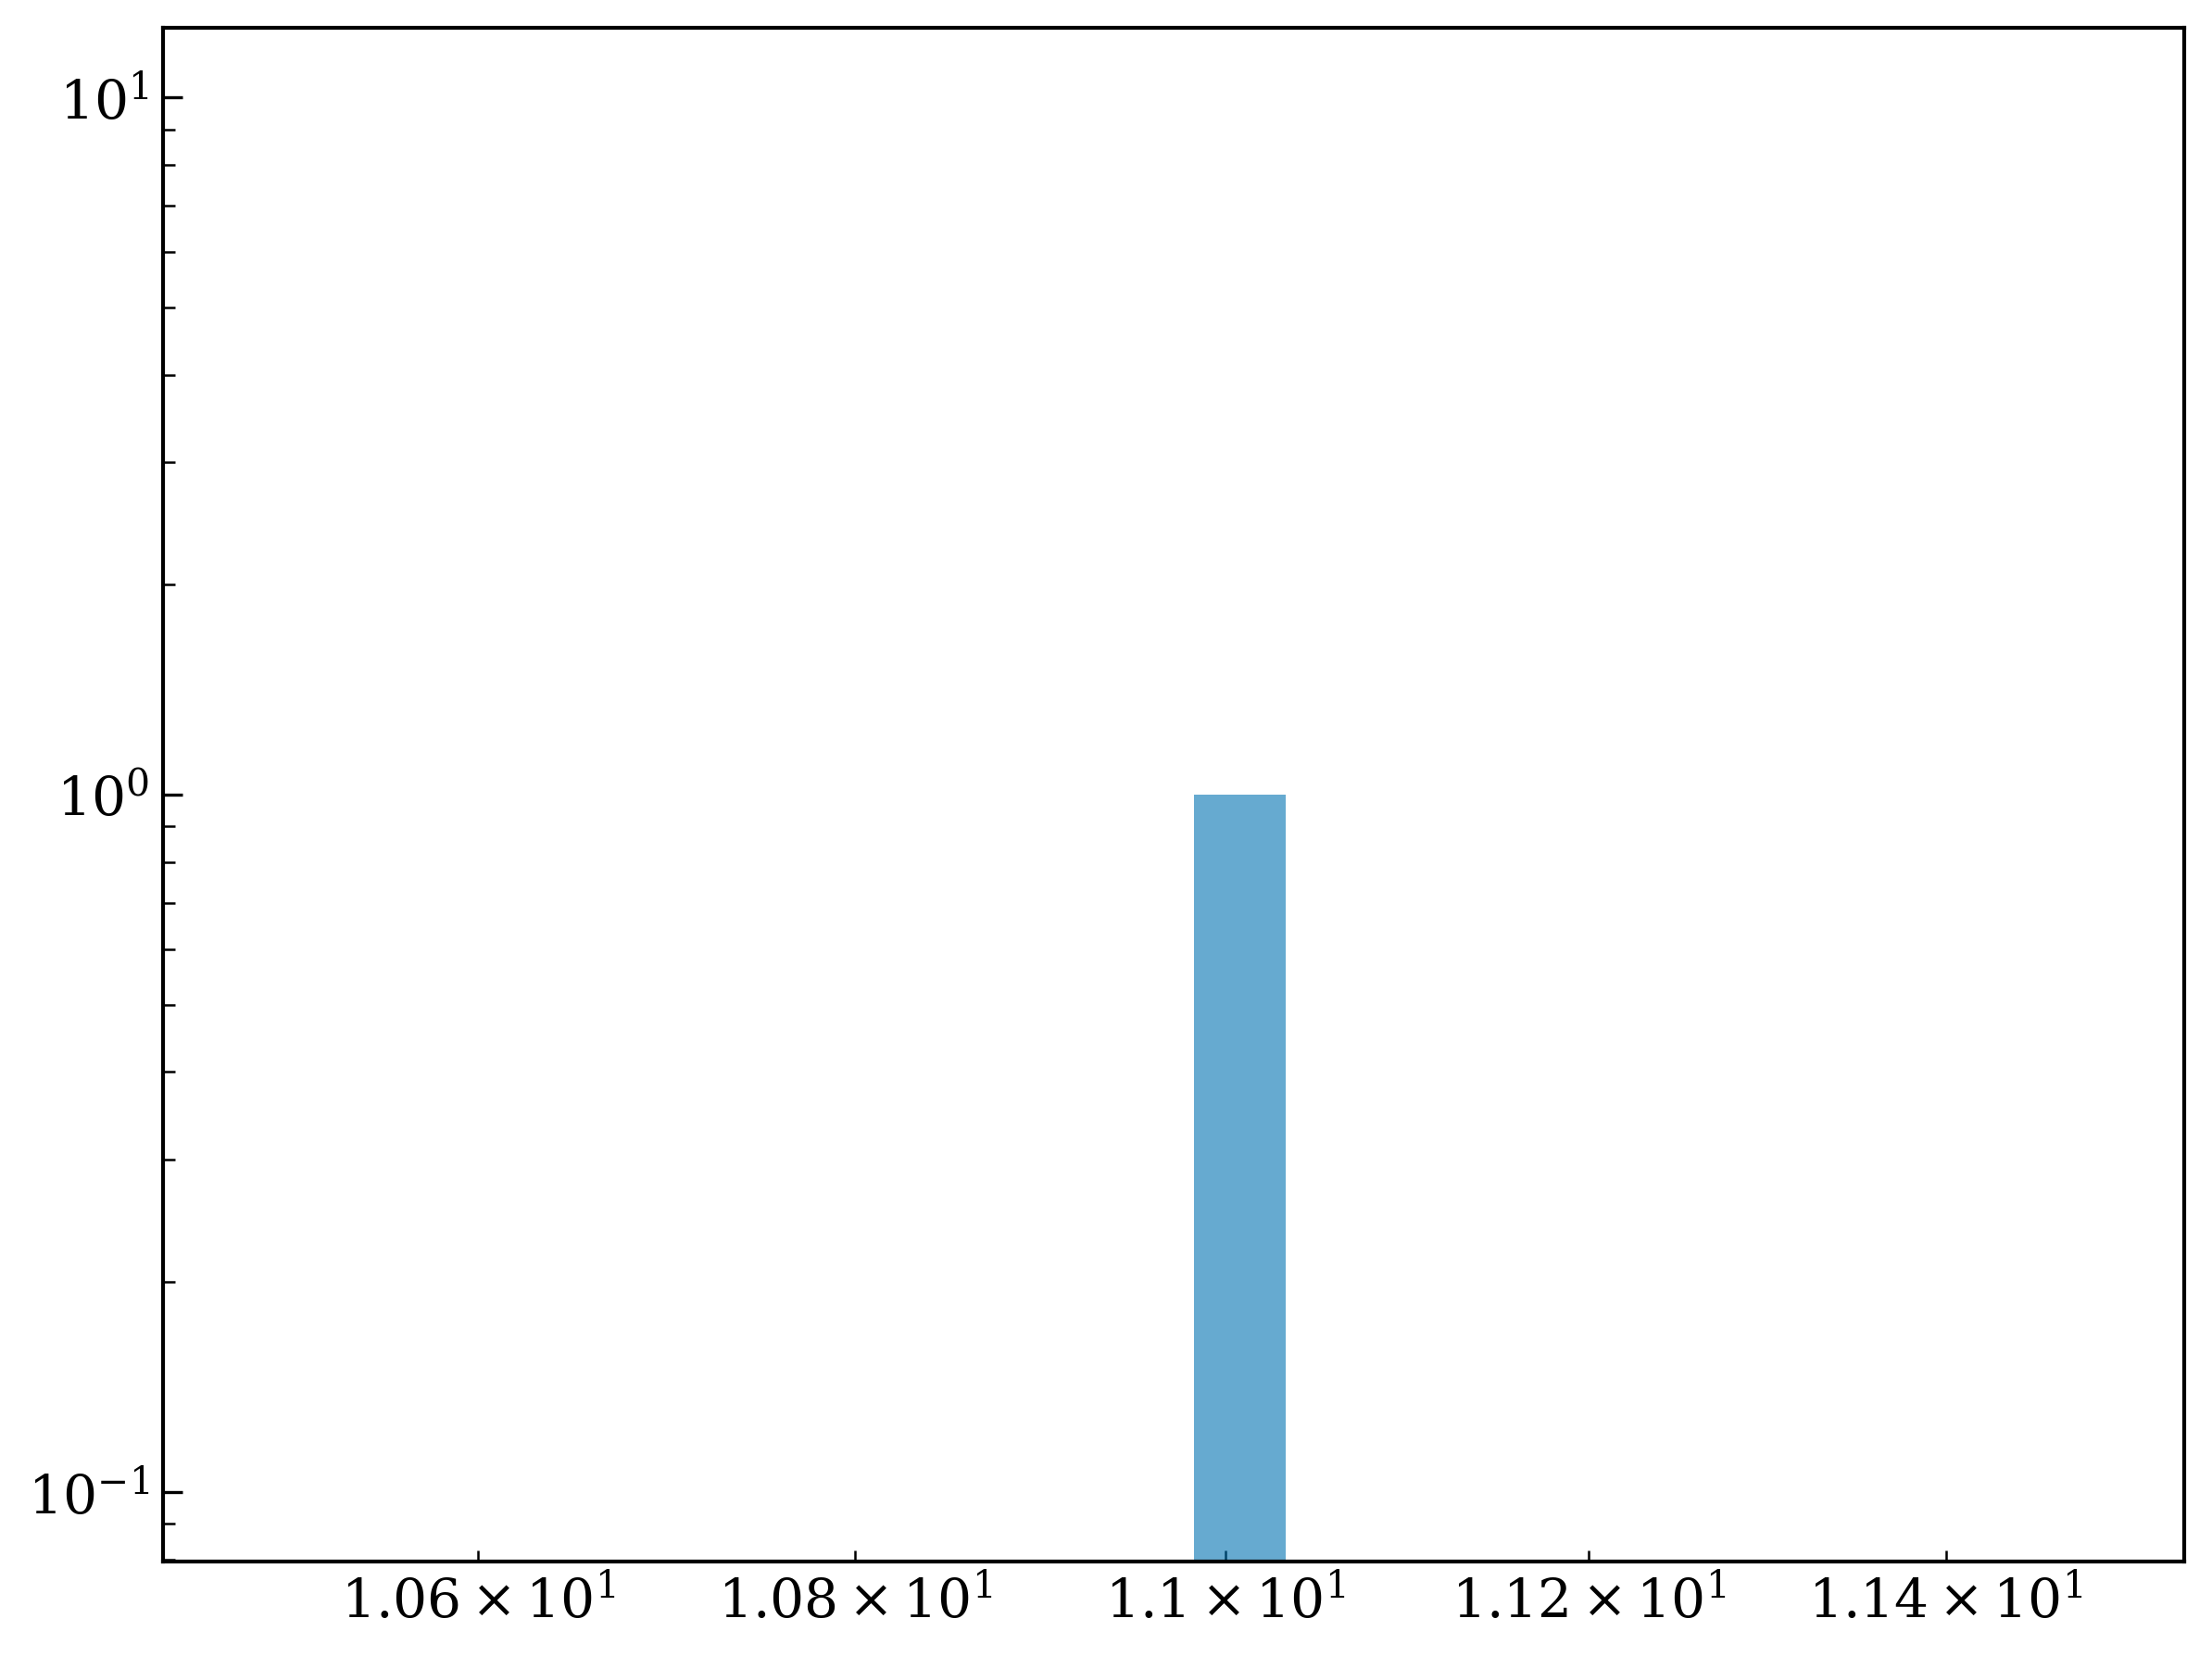

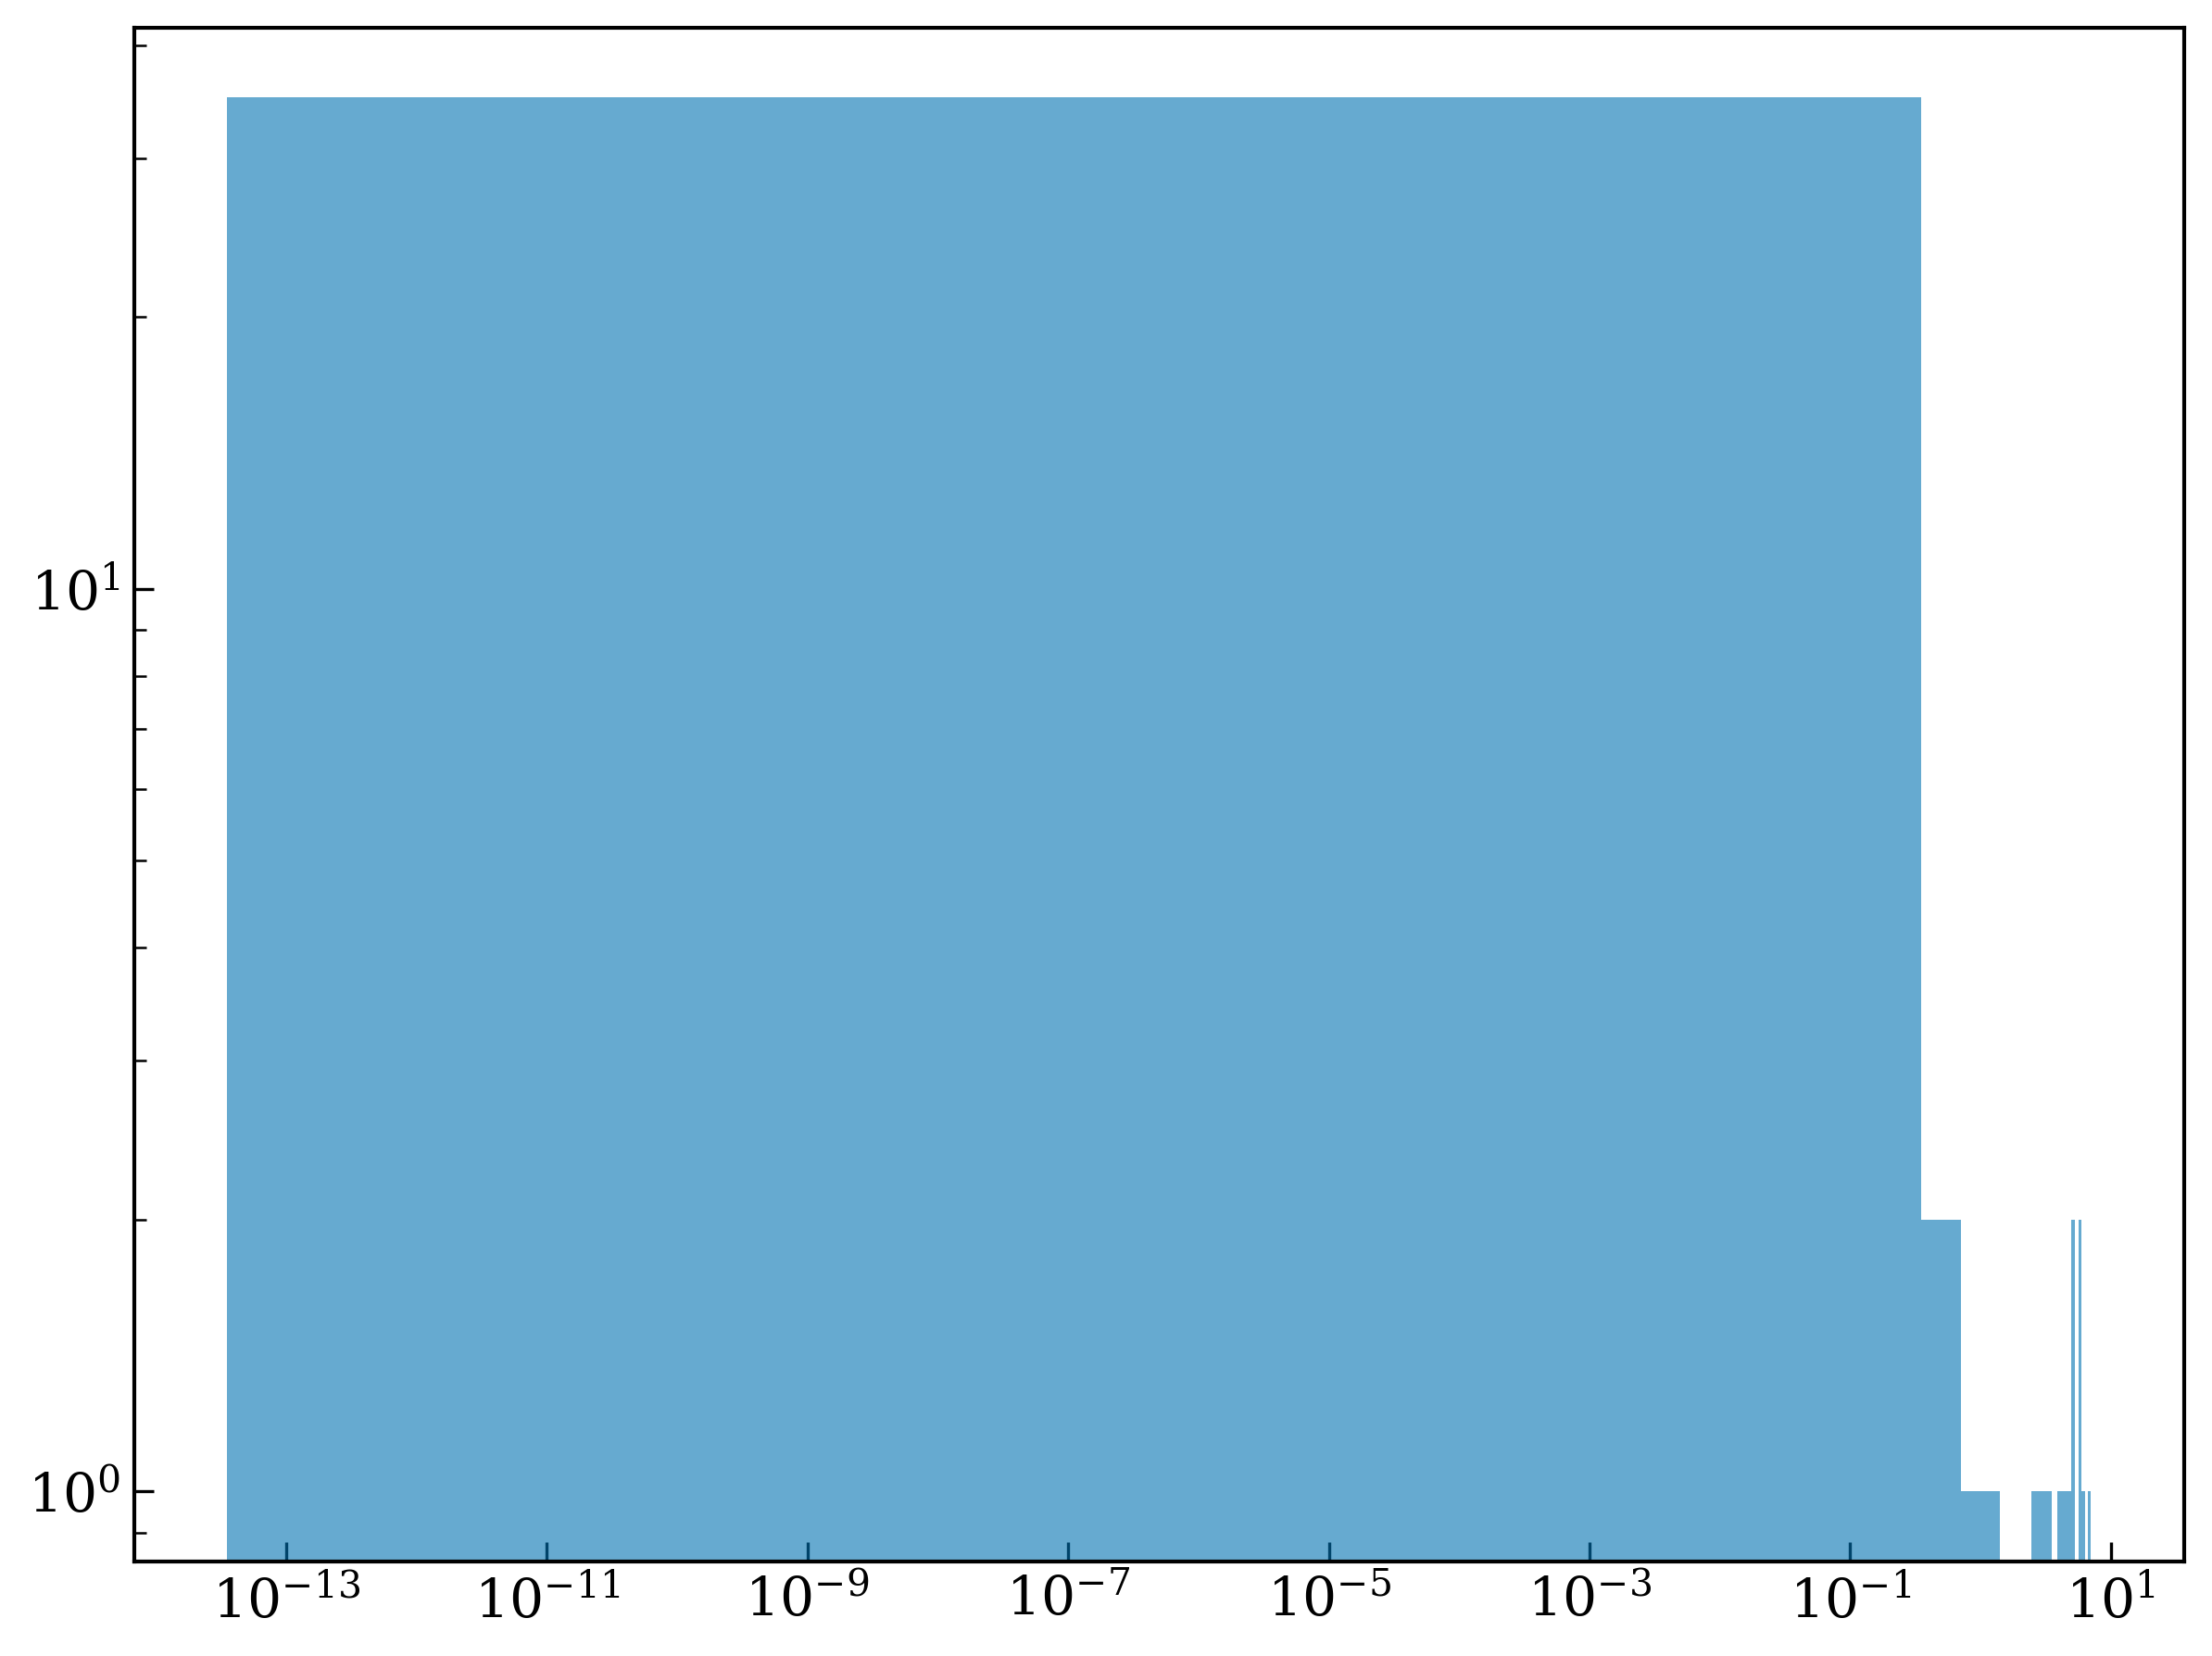

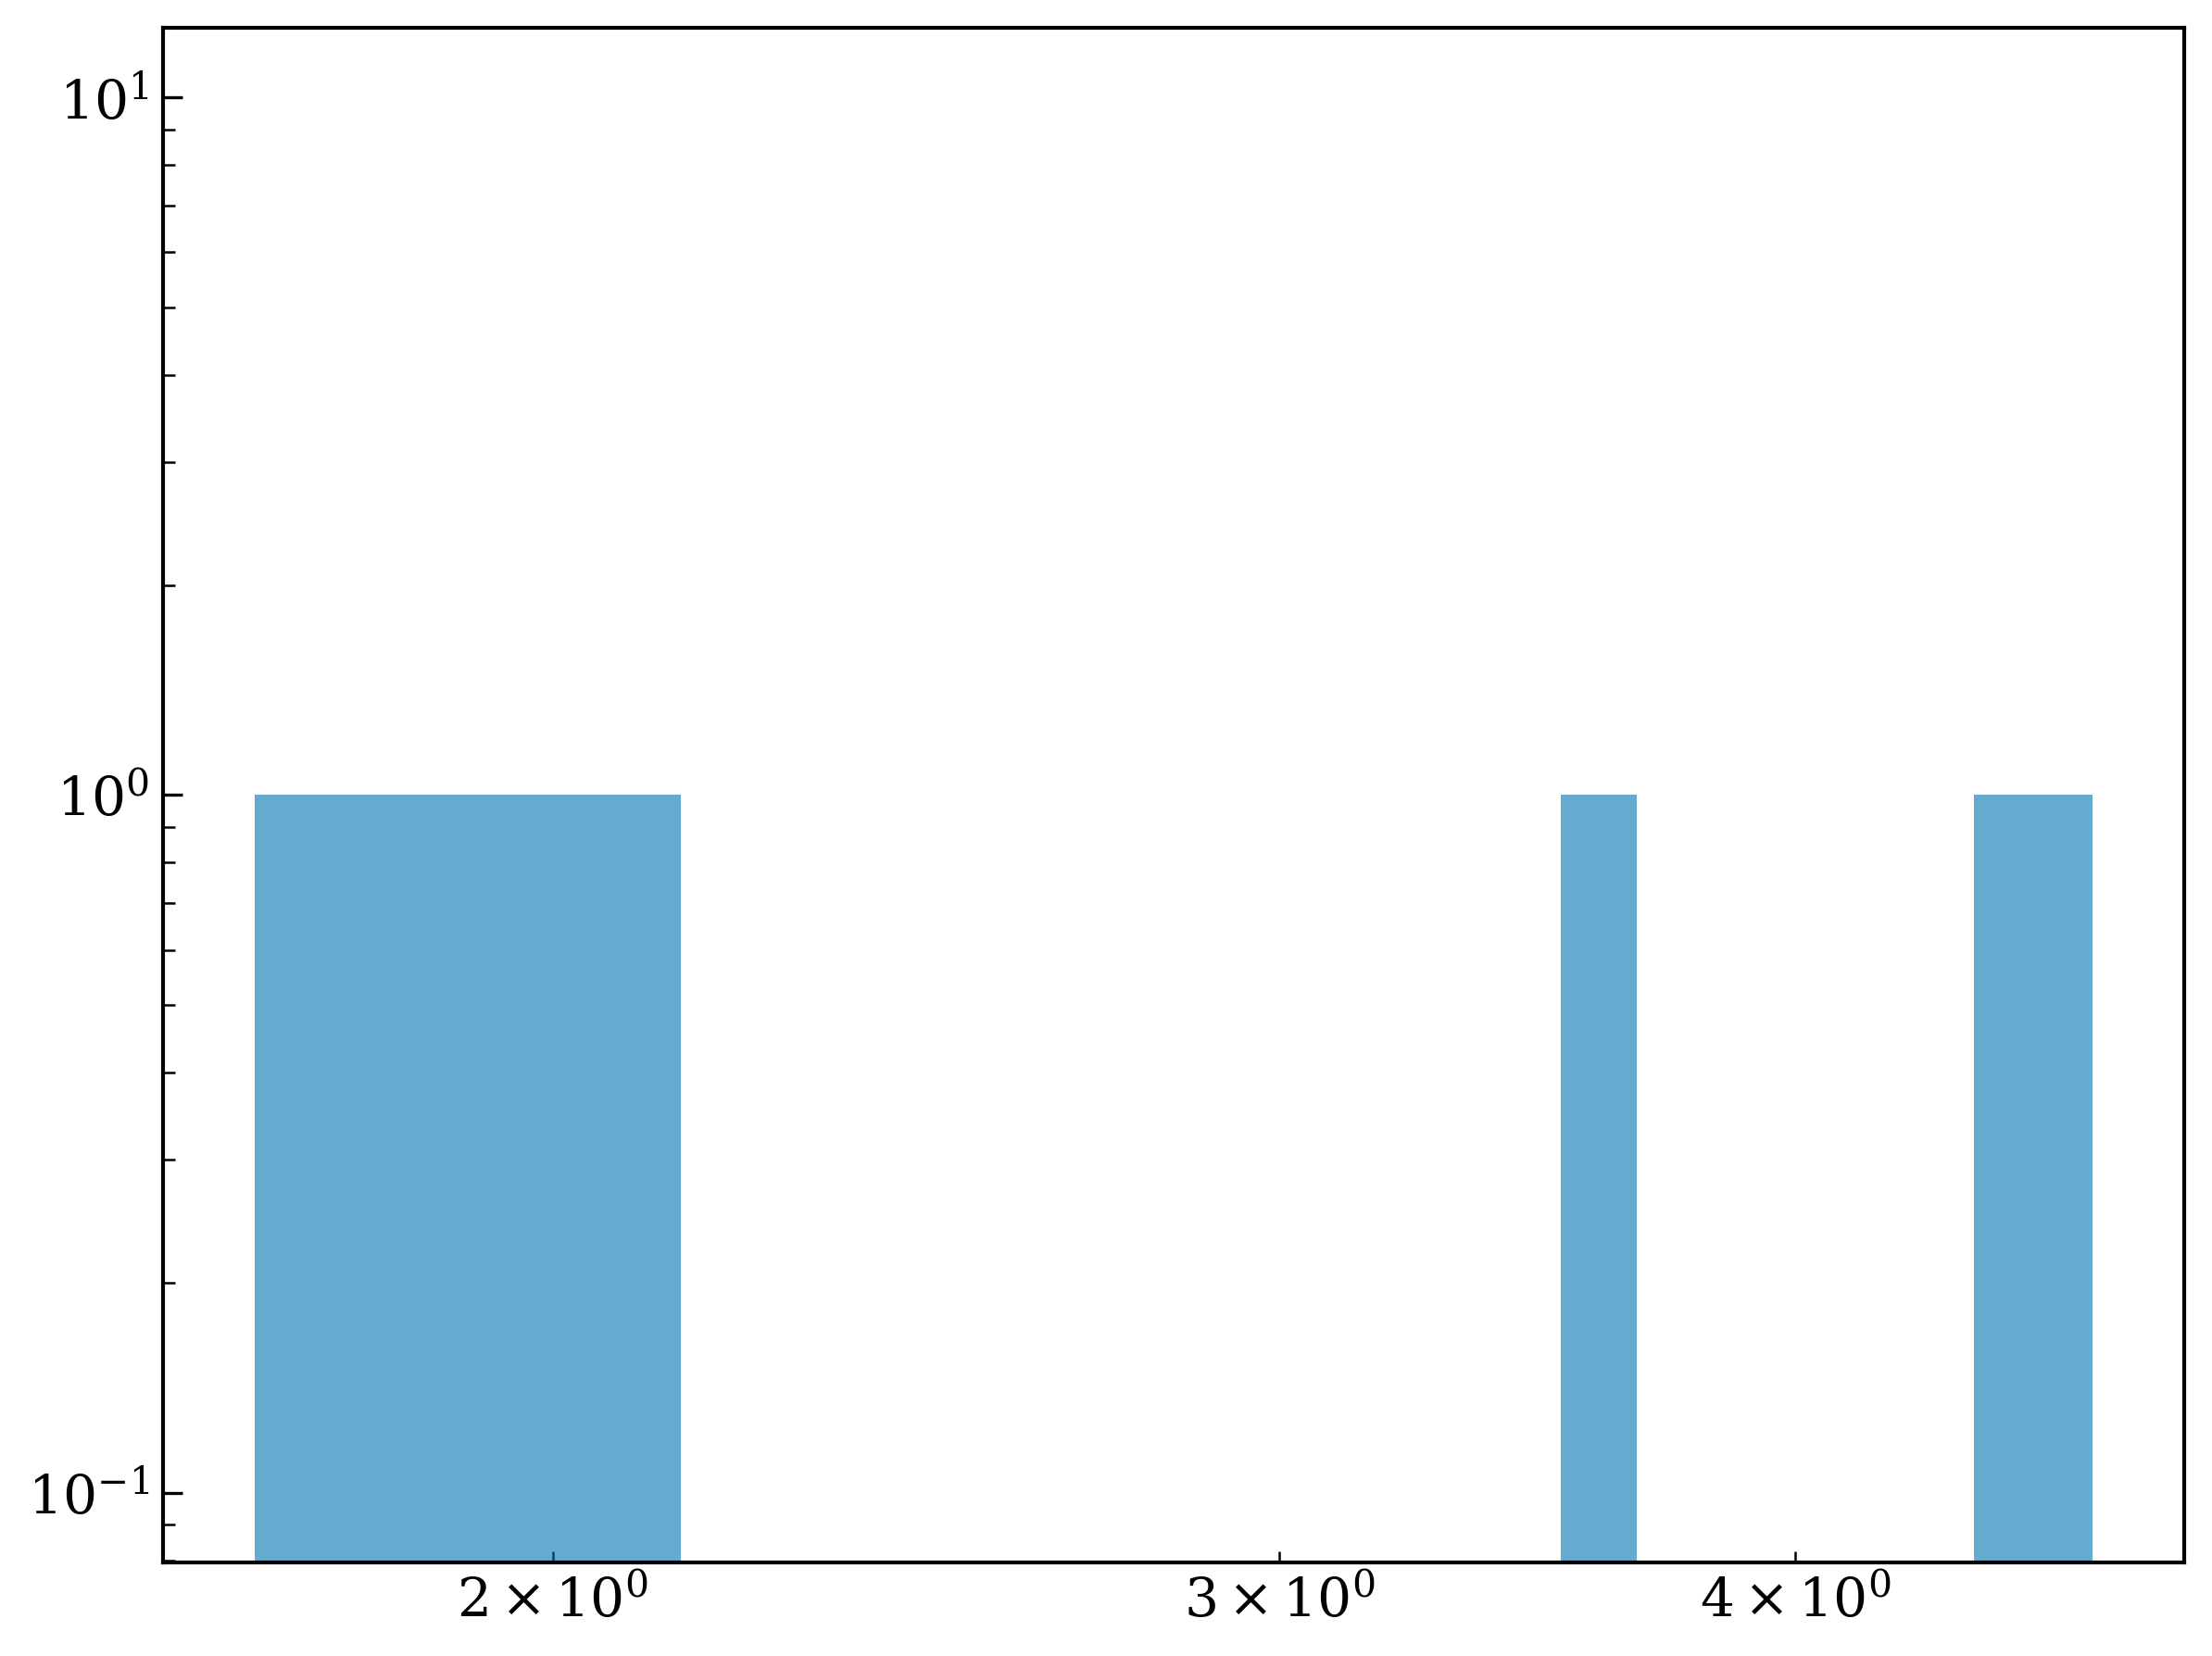

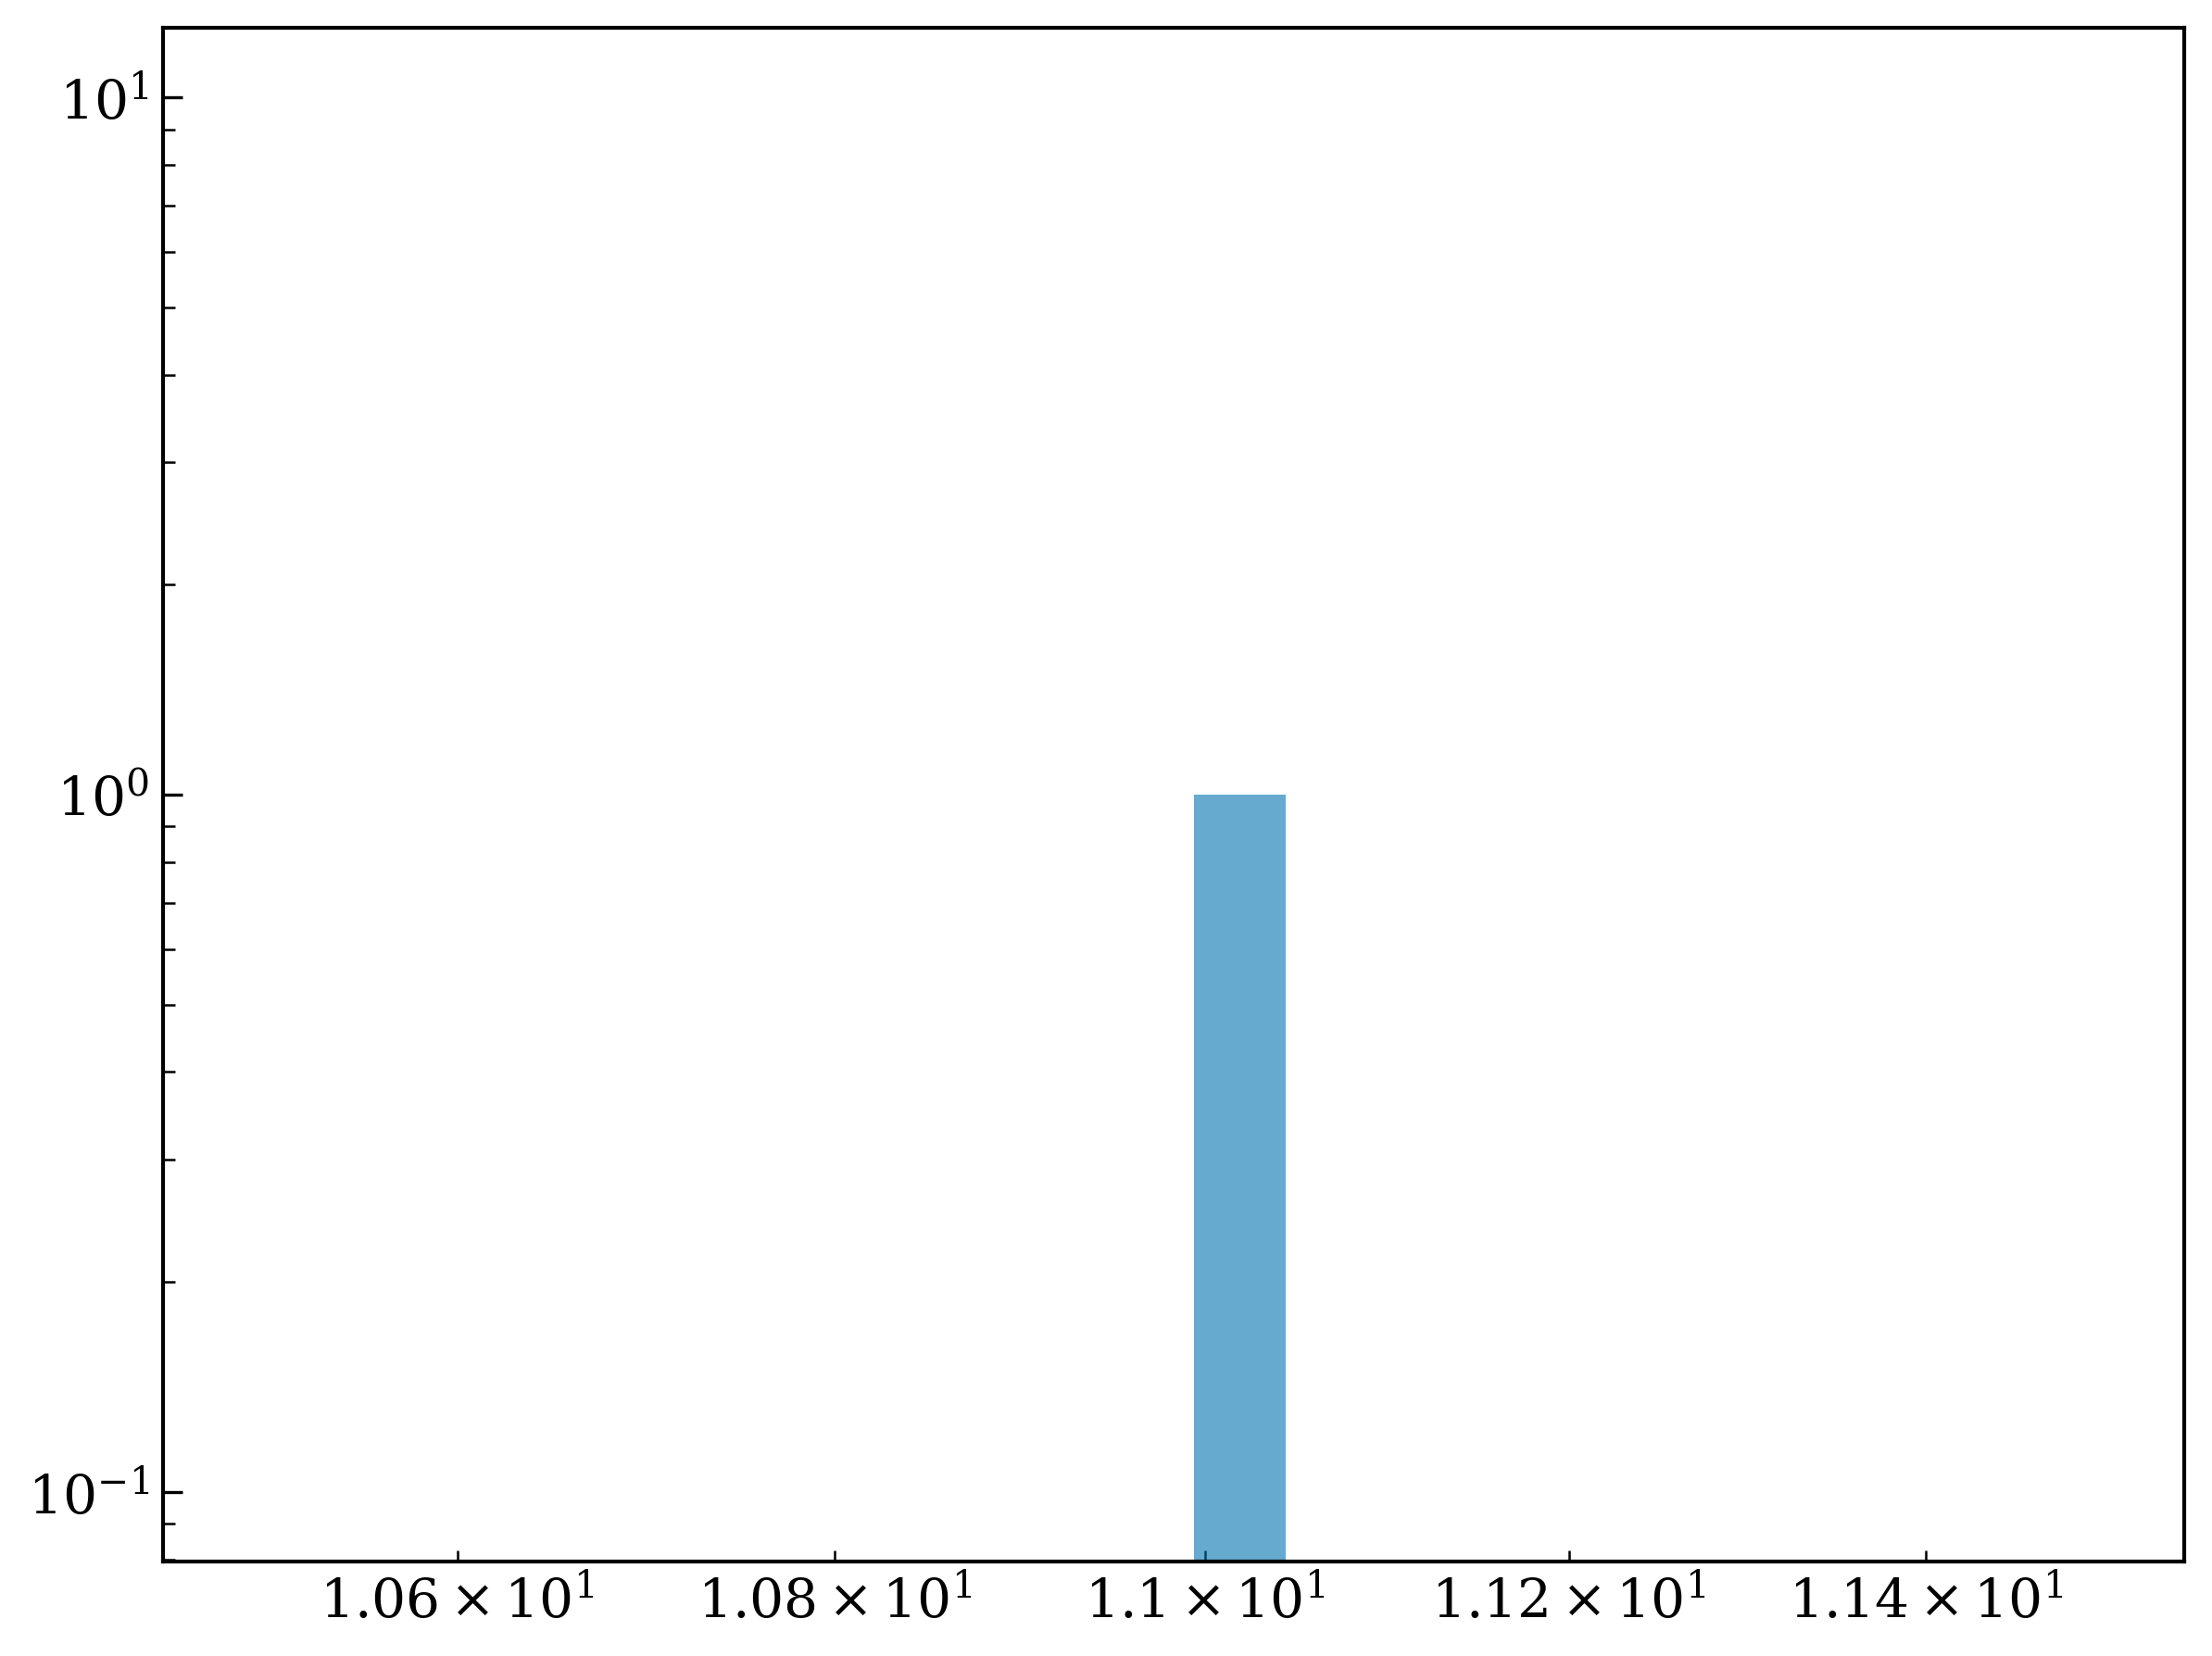

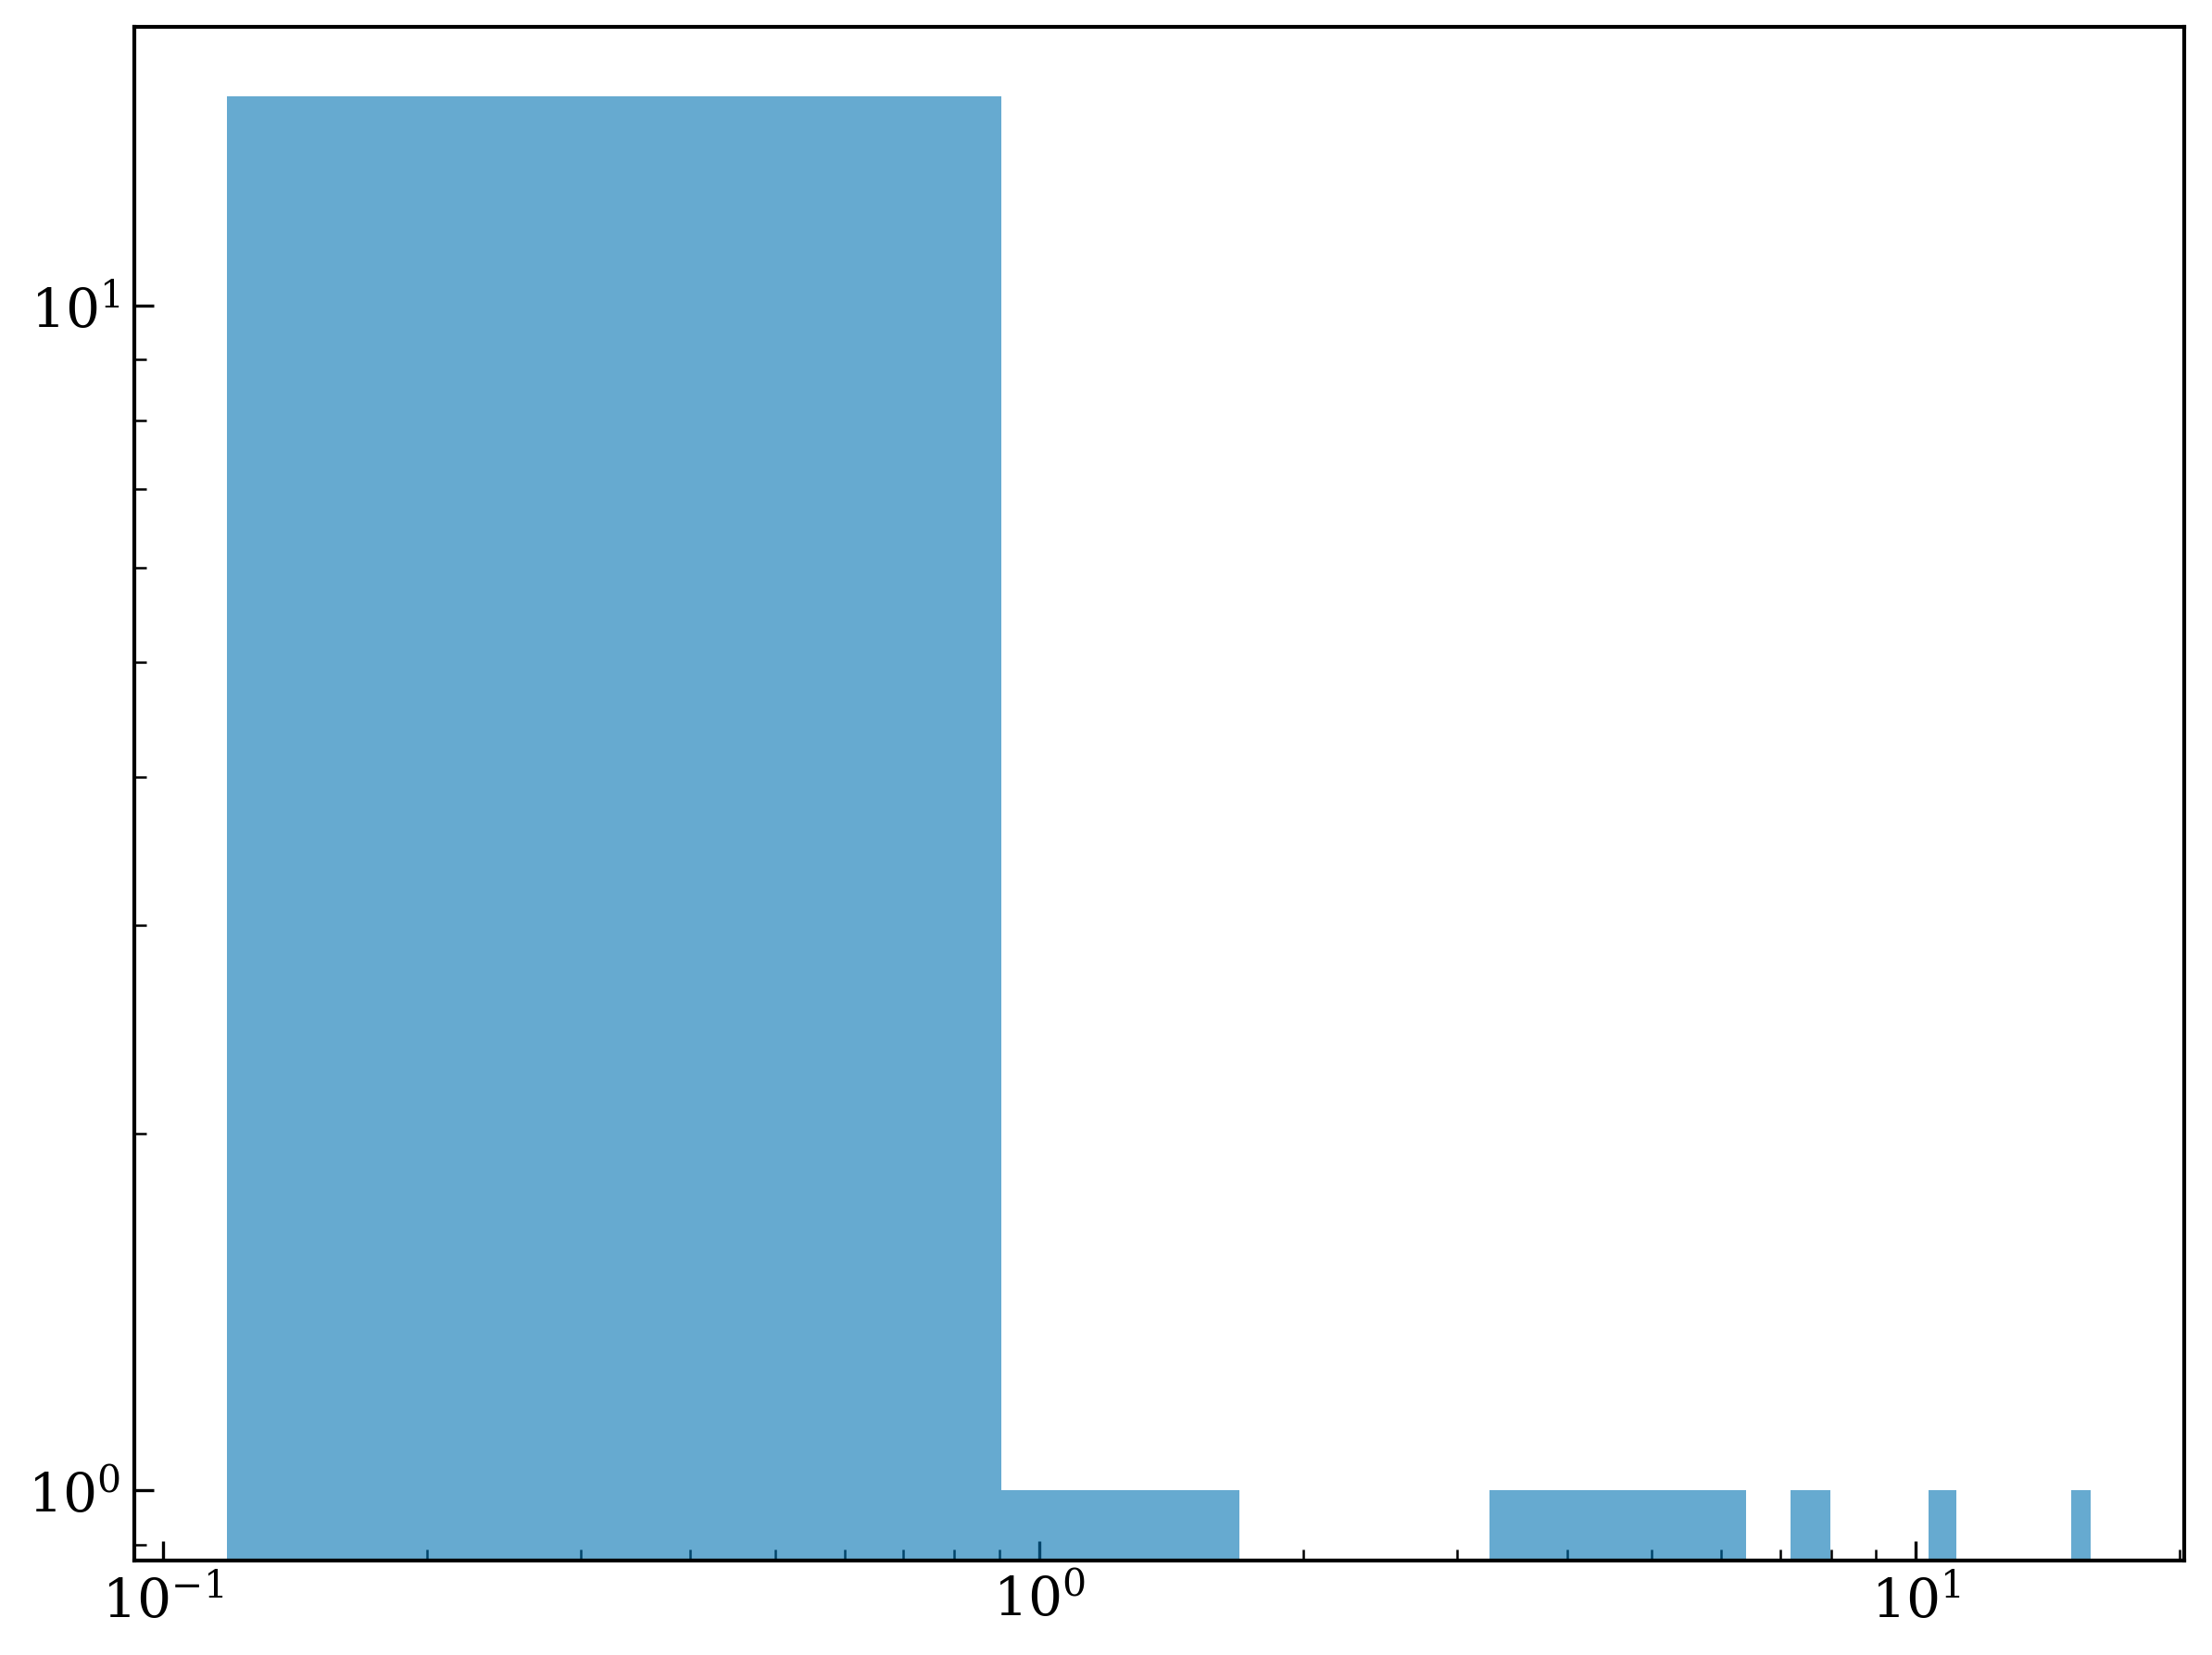

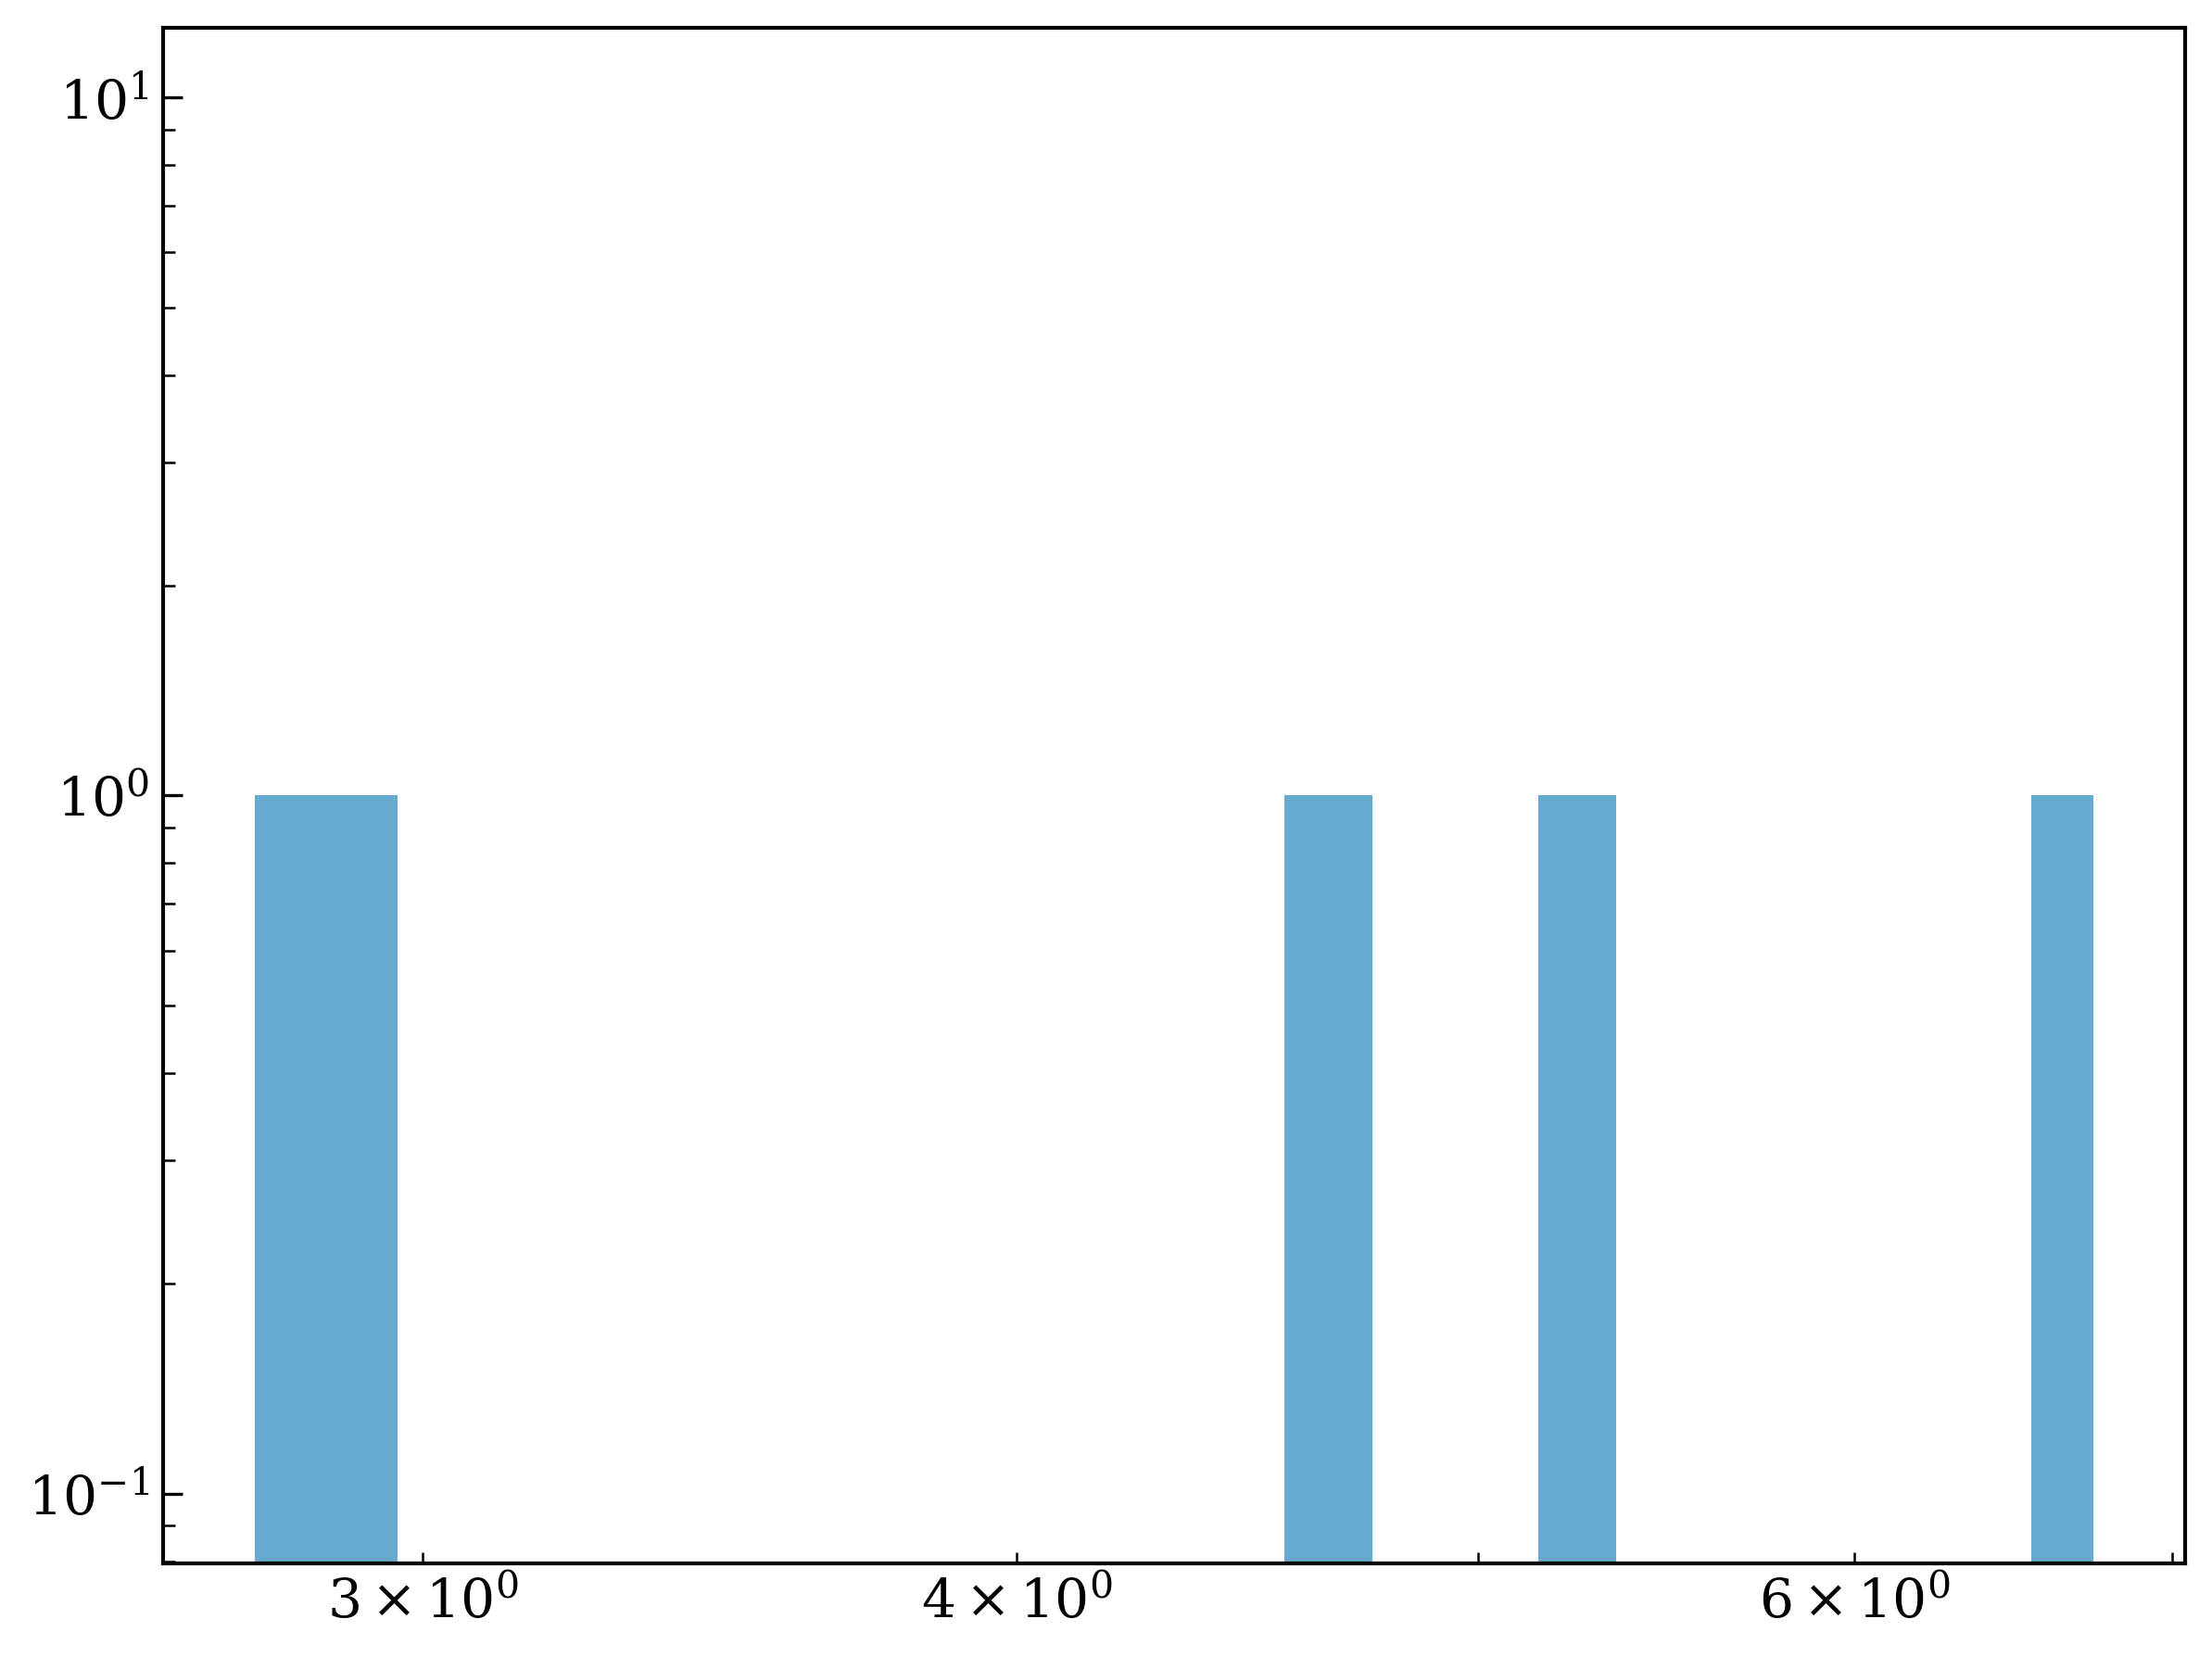

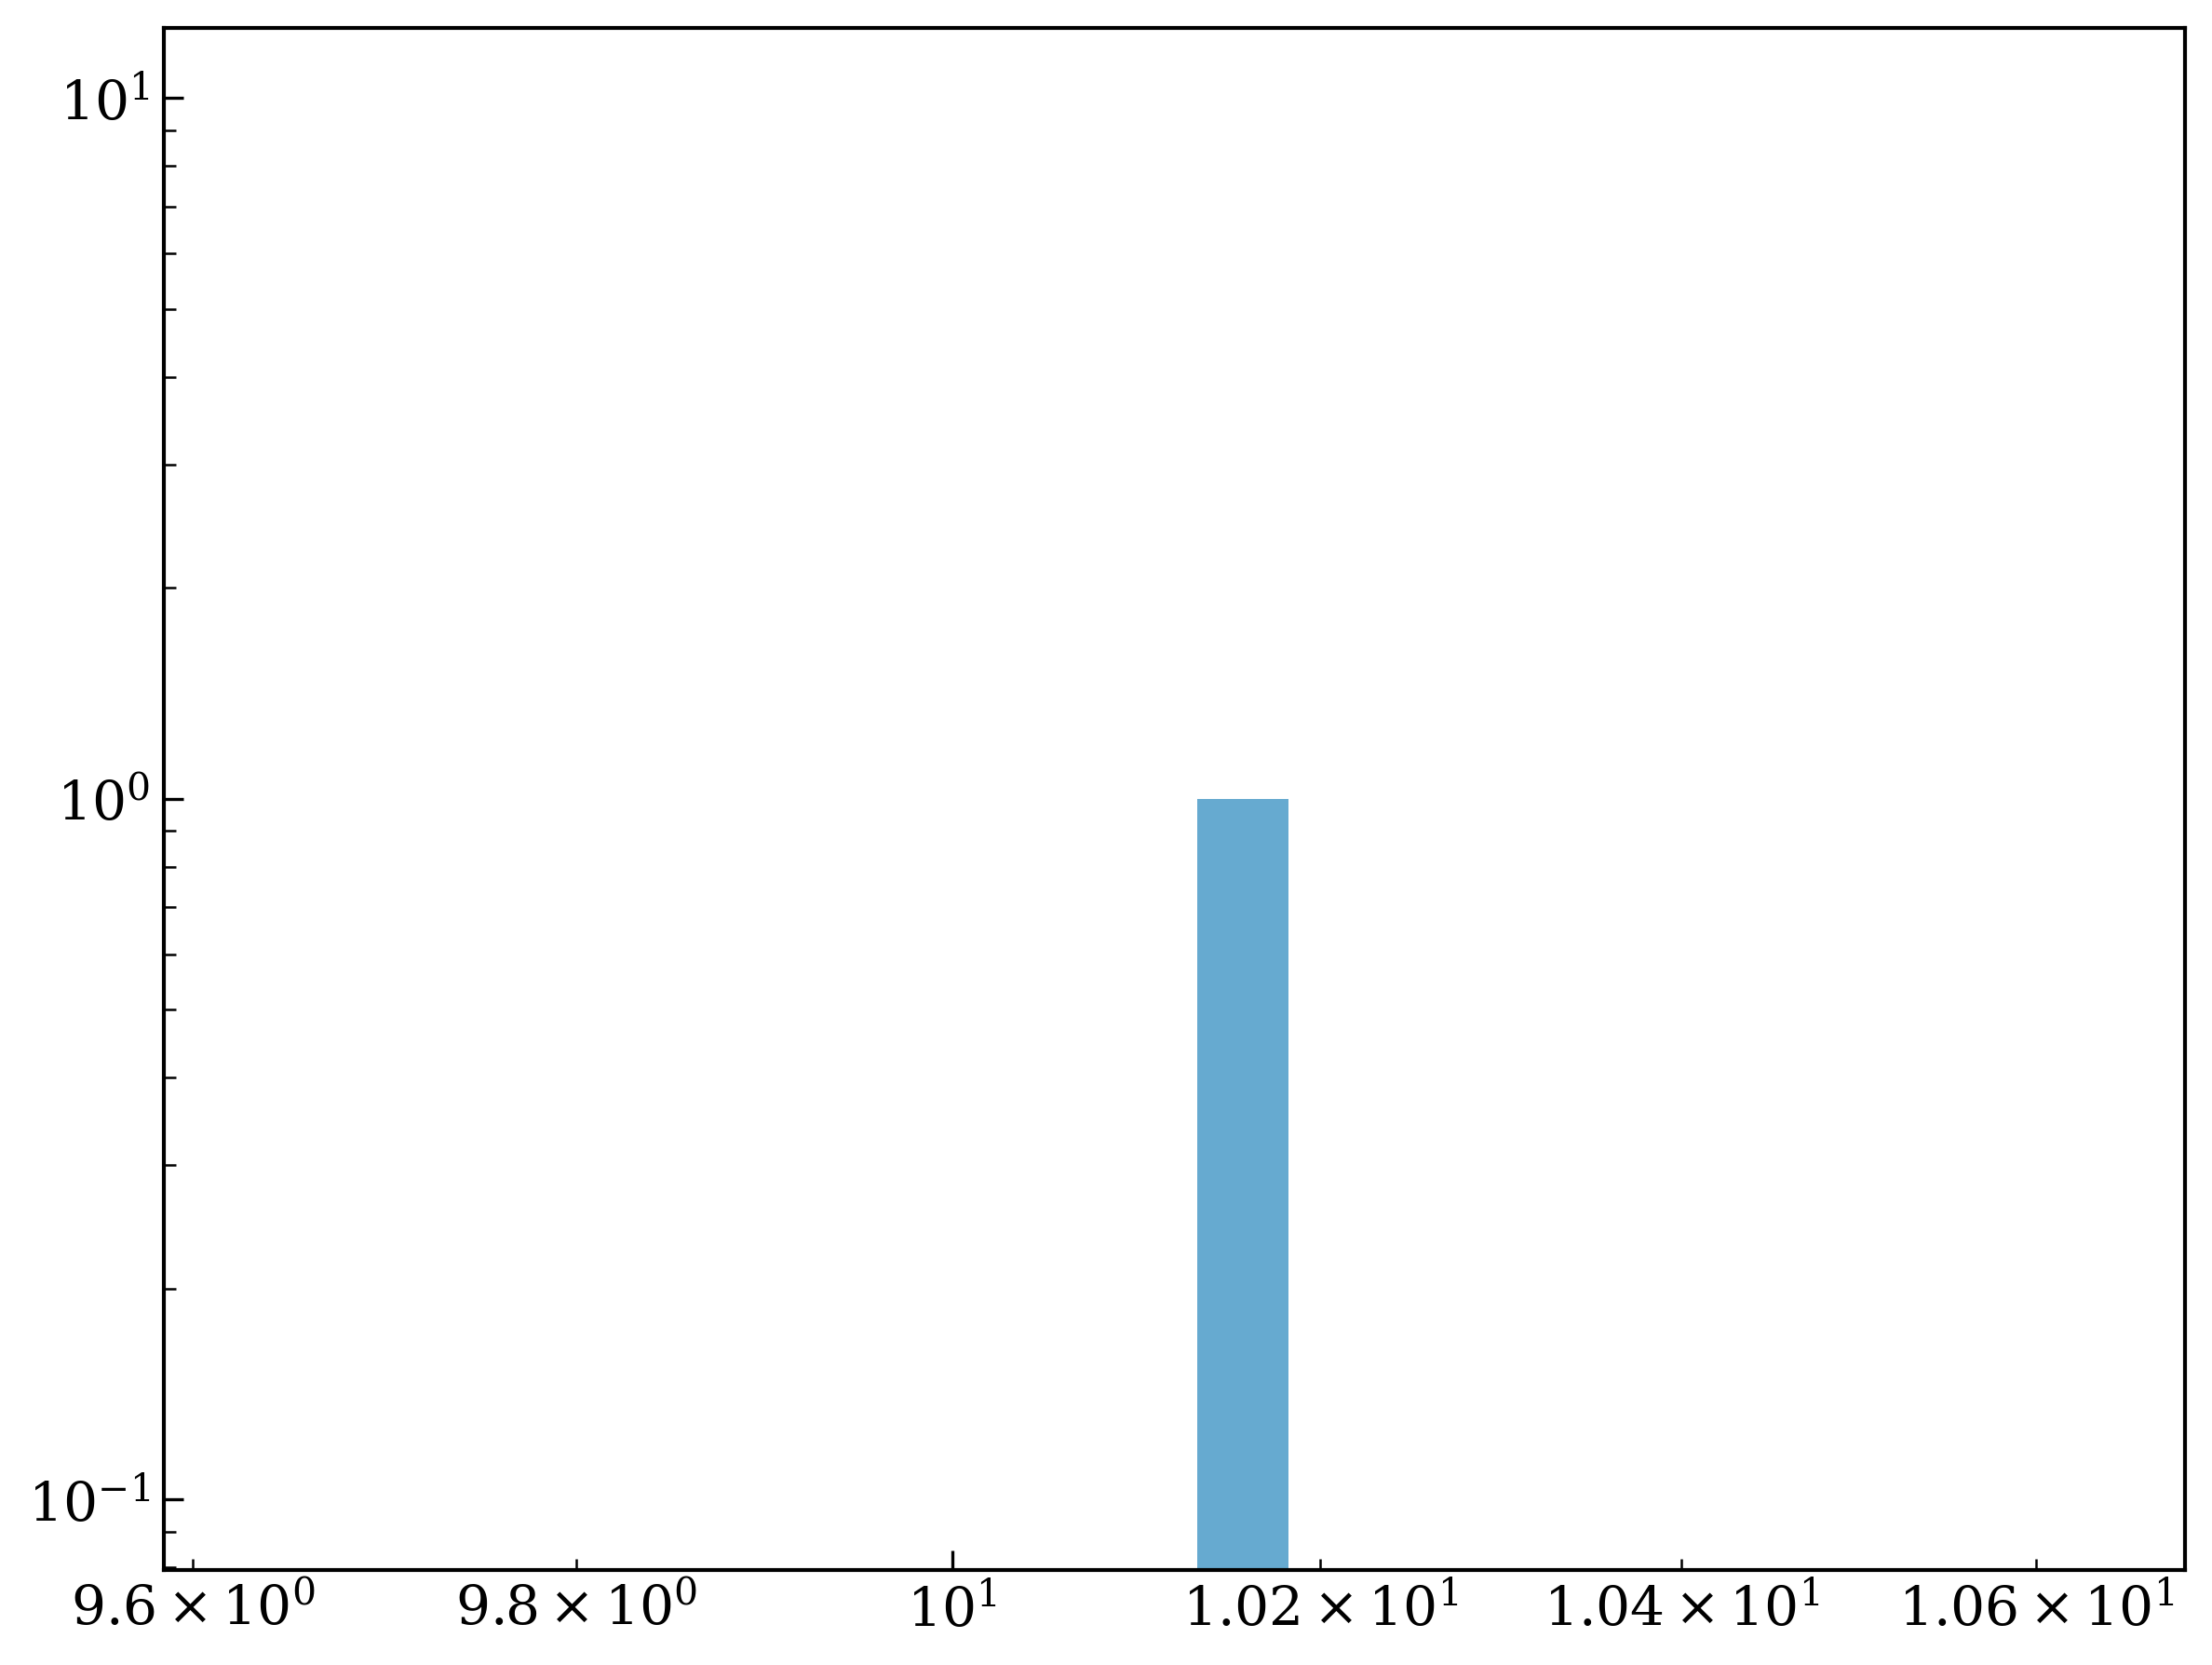

In [44]:
# (i + delta)^-a

for name, singular_values in svd.items():
    plt.hist(singular_values.numpy(), bins=20, alpha=0.6, label=name)

    plt.xscale('log')
    plt.yscale('log')

    plt.grid()
    plt.show()